<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [15]</a>'.</span>

# NB03: Multi-seed evaluation with dynamic feature-set winner selection

Tests three feature engineering methods (raw, alr, pwlr) across four tree
ensembles (RF, ERT, XGB, GB) for both `opx_liq` and `opx_only` tracks. Tuned
once on seed 42 with `HalvingRandomSearchCV` + `StratifiedGroupKFold`, then
frozen hyperparameters are evaluated on 9 additional split seeds (43-51) so
downstream selection can account for across-split variance.

The old factorial design included `raw_aug`, `alr_aug`, `pwlr_aug` variants.
The n_aug sensitivity appendix at the end of this notebook documents the
decision to drop them: see section "Appendix: N_AUG sensitivity".

Outputs:
- `results/nb03_multi_seed_results.csv`
- `results/nb03_winning_configurations.json`
- `results/nb03_canonical_test_predictions.npz`
- `figures/fig05_model_comparison.png` (downstream, from NB06)


## Purpose / Inputs / Outputs / Canonical decisions

**Purpose:** Multi-seed baseline-model evaluation. Tests three feature engineering methods (raw, alr, pwlr) across four tree ensembles (RF, ERT, XGB, GB) for opx-only and opx-liq tracks under a 10-fold StratifiedGroupKFold CV, repeated across 5 split seeds.

**Inputs:** `data/processed/opx_clean_opx_liq.parquet`, `data/processed/opx_clean_core.csv`, split-index arrays.

**Outputs:** `results/nb03_multi_seed_results.csv`, `results/nb03_multi_seed_summary.csv`, `results/nb03_winning_configurations.json` (read by every downstream notebook via `load_winning_config`), `models/model_<family>_<target>_<track>_<feat>.joblib`.

**Canonical decisions:** `nb03_winning_configurations.json` sets the **global** feature set (`WIN_FEAT`) that all downstream work consumes. Do not hard-code feature names elsewhere - route through `WIN_FEAT` and `canonical_model_filename`.


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    EXPETDB, LEPR_XLSX, LIN2023_NATURAL,
    FE3_FET_RATIO, KD_FEMG_MIN, KD_FEMG_MAX, WO_MAX_MOL_PCT,
    P_CEILING_KBAR, CATION_SUM_MIN, CATION_SUM_MAX,
    OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX,
    SEED_SPLIT, SEED_MODEL, SEED_NOISE_AUG, SEED_KMEANS,
        OPX_RAW_OXIDES, OPX_FULL_OXIDES, LIQ_OXIDES,
    N_SPLIT_REPS, SPLIT_SEEDS, FEATURE_METHODS,
    MODEL_FAMILIES, TIEBREAKER_RULE,
)
import warnings
warnings.filterwarnings('ignore')

import json
import logging
import shutil
import time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedGroupKFold, HalvingRandomSearchCV,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Local vs Colab pathing
if os.path.exists('/content'):
    TEMP_DIR = Path('/content')
else:
    TEMP_DIR = Path.cwd()

FIGS = FIGURES  # alias

In [2]:
# Load cleaned data with chemical cluster labels (written by NB02).
df_all = pd.read_parquet(DATA_PROC / 'opx_clean_core_with_clusters.parquet')
df_all = df_all.reset_index(drop=True)
print(f'Loaded: {len(df_all)} experiments, {df_all["Citation"].nunique()} studies')

df_opx = df_all.copy()
df_liq = df_all[df_all['opx_liq_pair']].reset_index(drop=True).copy()

print(f'Opx-only: {len(df_opx)} rows / {df_opx["Citation"].nunique()} studies')
print(f'Opx-liq:  {len(df_liq)} rows / {df_liq["Citation"].nunique()} studies')


Loaded: 1035 experiments, 123 studies
Opx-only: 1035 rows / 123 studies
Opx-liq:  600 rows / 93 studies


In [3]:
df_liq.to_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
df_opx.to_parquet(DATA_PROC / 'opx_clean_opx_only.parquet')
print('Track parquet files written.')

Track parquet files written.


In [4]:
# Canonical features and prediction helpers from src/ (one source of truth).
from src.features import (
    build_feature_matrix,
    make_raw_features,
    make_alr_features,
    make_pwlr_features,
    augment_dataframe,
)
from src.models import predict_median, predict_iqr


In [5]:
# Model definitions and global config. N_SPLIT_REPS, SPLIT_SEEDS,
# FEATURE_METHODS come from config.py. v7 Part G raises N_SPLIT_REPS
# from 10 to 20.
TUNE_SEED = 42
N_AUG = 1  # augmentation disabled per sensitivity test results

HALVING_CV = 3
HALVING_FACTOR = 3
SEARCH_NJOBS = -1     # use all cores for local run
ESTIMATOR_NJOBS = 1   # prevent loky oversubscription

BASE_MODELS = {
    'RF':  lambda: RandomForestRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS),
    'ERT': lambda: ExtraTreesRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS),
    'XGB': lambda: XGBRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS,
                                 verbosity=0, tree_method='hist'),
    'GB':  lambda: HistGradientBoostingRegressor(random_state=SEED_MODEL,
                                                  early_stopping=True,
                                                  validation_fraction=0.15,
                                                  n_iter_no_change=20),
}

PARAM_GRIDS = {
    'RF': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [0.33, 0.5, 0.66, 'sqrt'],
    },
    'ERT': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [0.33, 0.5, 0.66, 'sqrt'],
    },
    'XGB': {
        'n_estimators': [200, 500, 800],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [1, 5, 10],
    },
    'GB': {
        'max_iter': [200, 500, 800],
        'max_depth': [3, 5, 7, None],
        'learning_rate': [0.01, 0.05, 0.1],
        'min_samples_leaf': [10, 20, 40],
        'l2_regularization': [0.0, 0.1, 1.0],
        'max_leaf_nodes': [15, 31, 63],
    },
}


def tune_with_halving(X_tr, y_tr, X_te, y_te, model_name, target_name,
                      seed, groups_tr):
    """Seed 42 only. HalvingRandomSearchCV, grouped stratified inner CV."""
    base = BASE_MODELS[model_name]()
    grid = PARAM_GRIDS[model_name]
    y_bins = pd.qcut(y_tr, q=5, labels=False, duplicates='drop')
    sgkf = StratifiedGroupKFold(n_splits=HALVING_CV, shuffle=True,
                                random_state=seed)
    cv_iter = list(sgkf.split(X_tr, y_bins, groups=groups_tr))
    search = HalvingRandomSearchCV(
        base, grid, factor=HALVING_FACTOR, resource='n_samples',
        cv=cv_iter, scoring='neg_mean_squared_error',
        random_state=seed, n_jobs=SEARCH_NJOBS, refit=True,
    )
    search.fit(X_tr, y_tr)
    best = search.best_estimator_
    pred_tr = predict_median(best, X_tr)
    pred_te = predict_median(best, X_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    return {
        'model': best,
        'best_params': search.best_params_,
        'model_name': model_name,
        'target': target_name,
        'rmse_train': rmse_tr,
        'rmse_test': rmse_te,
        'mae_test': mean_absolute_error(y_te, pred_te),
        'r2_test': r2_score(y_te, pred_te),
        'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
    }


def eval_frozen(X_tr, y_tr, X_te, y_te, model_name, target_name,
                frozen_params):
    """Seeds 43-51. Clone, set frozen params, single fit."""
    est = clone(BASE_MODELS[model_name]())
    est.set_params(**frozen_params)
    est.fit(X_tr, y_tr)
    pred_tr = predict_median(est, X_tr)
    pred_te = predict_median(est, X_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    return {
        'model': est,
        'best_params': frozen_params,
        'model_name': model_name,
        'target': target_name,
        'rmse_train': rmse_tr,
        'rmse_test': rmse_te,
        'mae_test': mean_absolute_error(y_te, pred_te),
        'r2_test': r2_score(y_te, pred_te),
        'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
    }

## Phase 3.3a: N_AUG sensitivity (pre-training exploration)

Tests `n_aug in {1, 3, 5, 10, 15}` across all three representations, both targets, and both tracks with default RF and XGB hyperparameters, then runs a Wilcoxon signed-rank test (1 vs N) per representation. Augmentation either hurt or failed to significantly help in every cell, so the 3-method design uses N_AUG=1 (identity augmentation).

Writes:
- `results/nb03_n_aug_sensitivity.csv`
- `figures/fig_nb03_n_aug_sensitivity.png`
- `figures/fig_nb03_n_aug_overfit.png`

In [6]:
# Phase 3.3b: N_AUG sensitivity test
import time
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

N_AUG_TEST = [1, 3, 5, 10, 15]
AUG_TEST_MODELS = ['RF', 'XGB']
AUG_TEST_REPRS = ['raw', 'alr', 'pwlr']
AUG_TEST_TARGETS = ['T_C', 'P_kbar']

# v7 hotfix: sensitivity test subsets SPLIT_SEEDS to first 5 seeds.
# Main Phase 3.4 training below still uses all 20 seeds.
_SENS_SEEDS = SPLIT_SEEDS[:5]
n_aug_results = []
total_iters = (len(AUG_TEST_MODELS) * len(N_AUG_TEST) * len(AUG_TEST_REPRS)
               * len(_SENS_SEEDS) * len(AUG_TEST_TARGETS) * 2)
pbar = tqdm(total=total_iters, desc='N_AUG sensitivity')

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    for seed in _SENS_SEEDS:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        tr_pos, te_pos = next(gss.split(df_track, groups=df_track['Citation'].values))
        df_train = df_track.iloc[tr_pos].copy()
        df_test = df_track.iloc[te_pos].copy()

        for repr_name in AUG_TEST_REPRS:
            X_te, _ = build_feature_matrix(df_test, repr_name, use_liq)

            for n_aug in N_AUG_TEST:
                t0 = time.time()
                if n_aug > 1:
                    df_tr_aug = augment_dataframe(df_train, n_aug=n_aug, seed=seed)
                else:
                    df_tr_aug = df_train.copy()

                X_tr, _ = build_feature_matrix(df_tr_aug, repr_name, use_liq)

                for target in AUG_TEST_TARGETS:
                    y_tr = df_tr_aug[target].values
                    y_te = df_test[target].values

                    for model_name in AUG_TEST_MODELS:
                        est = BASE_MODELS[model_name]()
                        est.fit(X_tr, y_tr)
                        pred_te = predict_median(est, X_te)
                        pred_tr = predict_median(est, X_tr)
                        rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
                        rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))

                        n_aug_results.append({
                            'track': track_name,
                            'model': model_name,
                            'repr': repr_name,
                            'target': target,
                            'n_aug': n_aug,
                            'seed': seed,
                            'rmse_test': rmse_te,
                            'rmse_train': rmse_tr,
                            'r2_test': r2_score(y_te, pred_te),
                            'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
                        })
                        pbar.update(1)
                        pbar.set_postfix(trk=track_name, m=model_name, r=repr_name,
                                         n=n_aug, s=seed, t=target)

pbar.close()
df_naug = pd.DataFrame(n_aug_results)
df_naug.to_csv(RESULTS / 'nb03_n_aug_sensitivity.csv', index=False)

# ----- Summary table -----
print('=' * 70)
print('N_AUG SENSITIVITY RESULTS (mean +/- std test RMSE)')
print('=' * 70)

summary = (df_naug.groupby(['model', 'track', 'repr', 'target', 'n_aug'])
           .agg(rmse_mean=('rmse_test', 'mean'),
                rmse_std=('rmse_test', 'std'),
                overfit_mean=('overfit_ratio', 'mean'))
           .reset_index())

for (model, track, target), grp in summary.groupby(['model', 'track', 'target']):
    print(f'\n--- {model} | {track} / {target} ---')
    pivot = grp.pivot(index='n_aug', columns='repr', values='rmse_mean')
    pivot_std = grp.pivot(index='n_aug', columns='repr', values='rmse_std')
    for col in pivot.columns:
        pivot[col] = [f'{m:.1f} +/- {s:.1f}'
                      for m, s in zip(pivot[col], pivot_std[col])]
    print(pivot.to_string())

# ----- Wilcoxon signed-rank: n_aug=1 vs each n_aug -----
print('\n' + '=' * 70)
print('WILCOXON SIGNED-RANK TESTS (n_aug=1 vs n_aug=N)')
print('=' * 70)

for (model, track, repr_name, target), grp in df_naug.groupby(['model', 'track', 'repr', 'target']):
    baseline = grp[grp['n_aug'] == 1].sort_values('seed')['rmse_test'].values
    best_rmse, best_n = baseline.mean(), 1
    for n in [3, 5, 10, 15]:
        cand = grp[grp['n_aug'] == n].sort_values('seed')['rmse_test'].values
        if len(cand) == len(baseline):
            delta = baseline - cand
            try:
                stat, p = stats.wilcoxon(delta, alternative='two-sided')
            except ValueError:
                stat, p = np.nan, np.nan
            mean_d = delta.mean()
            direction = 'HELPS' if mean_d > 0 else 'HURTS'
            sig = '*' if p < (0.05 / 4) else ''
            print(f'{model:4s} {track:10s} {repr_name:5s} {target:7s} '
                  f'1 vs {n:2d}: delta={mean_d:+.2f}  p={p:.4f} {sig} {direction}')
            if cand.mean() < best_rmse:
                best_rmse, best_n = cand.mean(), n
    print(f'  -> Best n_aug for {model}/{repr_name}/{target}: {best_n}')

N_AUG sensitivity:   0%|          | 0/600 [00:00<?, ?it/s]

N_AUG SENSITIVITY RESULTS (mean +/- std test RMSE)

--- RF | opx_liq / P_kbar ---
repr           alr         pwlr          raw
n_aug                                       
1      6.2 +/- 0.8  6.2 +/- 1.0  5.6 +/- 0.8
3      7.0 +/- 1.3  6.1 +/- 1.2  5.8 +/- 0.5
5      7.1 +/- 1.5  6.3 +/- 1.1  5.9 +/- 0.8
10     7.4 +/- 1.5  6.3 +/- 1.0  6.4 +/- 0.6
15     7.4 +/- 1.4  6.6 +/- 1.1  6.4 +/- 0.5

--- RF | opx_liq / T_C ---
repr              alr           pwlr            raw
n_aug                                              
1        82.9 +/- 7.2   81.3 +/- 6.9   81.3 +/- 9.2
3       90.0 +/- 12.4   94.2 +/- 6.8   88.0 +/- 9.9
5       92.2 +/- 14.0   93.3 +/- 7.8   90.7 +/- 9.7
10      97.3 +/- 13.7   90.0 +/- 9.0  94.0 +/- 13.5
15     100.1 +/- 13.7  92.1 +/- 10.4  94.7 +/- 13.6

--- RF | opx_only / P_kbar ---
repr            alr          pwlr           raw
n_aug                                          
1      13.5 +/- 3.9  12.6 +/- 3.4  14.2 +/- 3.1
3      15.1 +/- 2.6  13.3 +/- 3.2  

XGB  opx_only   raw   T_C     1 vs  3: delta=-5.57  p=0.0625  HURTS
XGB  opx_only   raw   T_C     1 vs  5: delta=-9.02  p=0.1250  HURTS
XGB  opx_only   raw   T_C     1 vs 10: delta=-7.14  p=0.0625  HURTS
XGB  opx_only   raw   T_C     1 vs 15: delta=-9.06  p=0.1250  HURTS
  -> Best n_aug for XGB/raw/T_C: 1


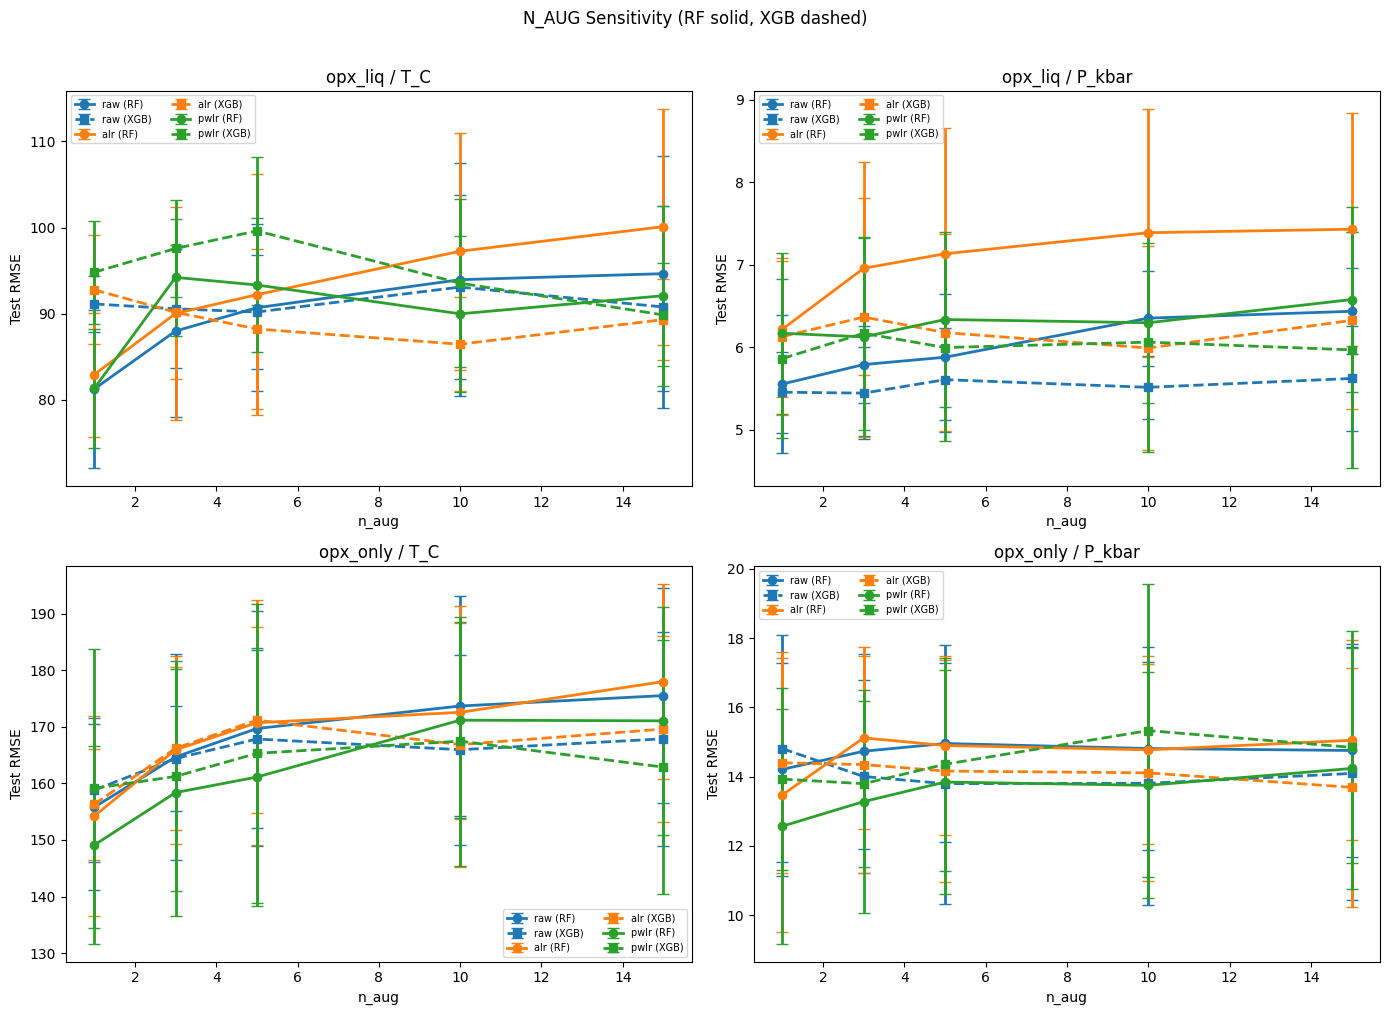

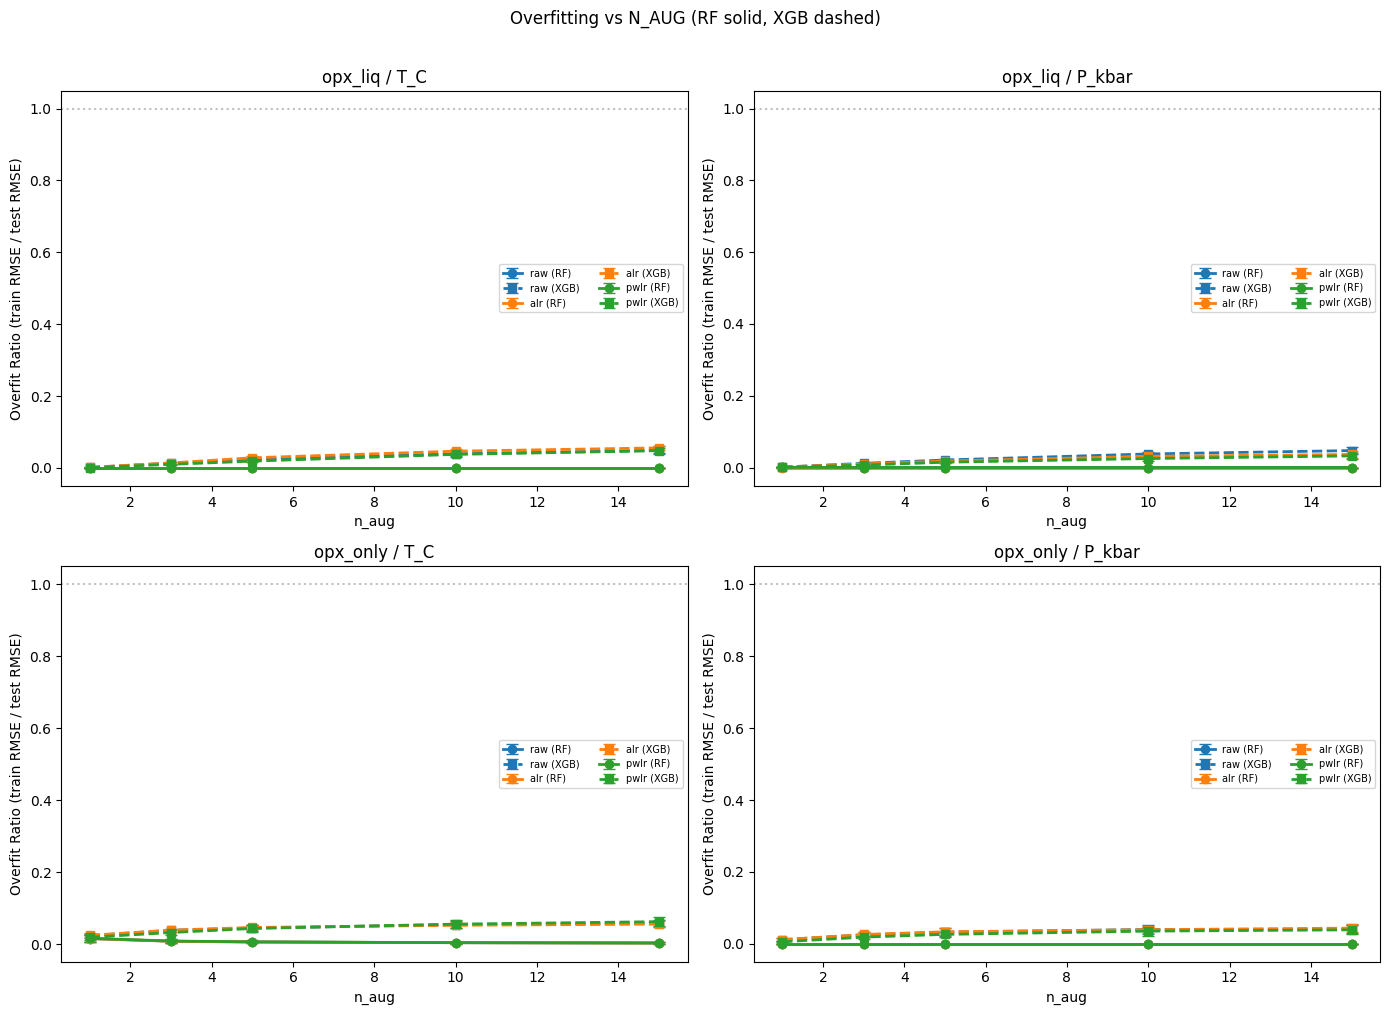


>>> SET N_AUG in the next cell based on these results <<<


In [7]:
# ----- Error bar plot: RMSE vs n_aug -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panels = [('opx_liq', 'T_C'), ('opx_liq', 'P_kbar'),
          ('opx_only', 'T_C'), ('opx_only', 'P_kbar')]
colors = {'raw': '#1f77b4', 'alr': '#ff7f0e', 'pwlr': '#2ca02c'}
markers = {'RF': 'o', 'XGB': 's'}

for ax, (track, target) in zip(axes.flat, panels):
    for repr_name, color in colors.items():
        for model_name, marker in markers.items():
            sub = df_naug[(df_naug['track'] == track) &
                          (df_naug['target'] == target) &
                          (df_naug['repr'] == repr_name) &
                          (df_naug['model'] == model_name)]
            m = sub.groupby('n_aug')['rmse_test'].mean()
            s = sub.groupby('n_aug')['rmse_test'].std()
            ax.errorbar(m.index, m.values, yerr=s.values, marker=marker,
                        label=f'{repr_name} ({model_name})', color=color,
                        capsize=4, linewidth=2,
                        linestyle='-' if model_name == 'RF' else '--')
    ax.set_xlabel('n_aug')
    ax.set_ylabel('Test RMSE')
    ax.set_title(f'{track} / {target}')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('N_AUG Sensitivity (RF solid, XGB dashed)', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03_n_aug_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# ----- Overfit ratio plot -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (track, target) in zip(axes.flat, panels):
    for repr_name, color in colors.items():
        for model_name, marker in markers.items():
            sub = df_naug[(df_naug['track'] == track) &
                          (df_naug['target'] == target) &
                          (df_naug['repr'] == repr_name) &
                          (df_naug['model'] == model_name)]
            m = sub.groupby('n_aug')['overfit_ratio'].mean()
            s = sub.groupby('n_aug')['overfit_ratio'].std()
            ax.errorbar(m.index, m.values, yerr=s.values, marker=marker,
                        label=f'{repr_name} ({model_name})', color=color,
                        capsize=4, linewidth=2,
                        linestyle='-' if model_name == 'RF' else '--')
    ax.axhline(y=1.0, color='gray', alpha=0.5, linestyle=':')
    ax.set_xlabel('n_aug')
    ax.set_ylabel('Overfit Ratio (train RMSE / test RMSE)')
    ax.set_title(f'{track} / {target}')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Overfitting vs N_AUG (RF solid, XGB dashed)', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03_n_aug_overfit.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n>>> SET N_AUG in the next cell based on these results <<<')

## Phase 3.3b: Optuna TPE hyperparameter search (pre-training)

**What this replaces.** v7 and v8 used `HalvingRandomSearchCV`. Halving allocates more CV budget to survivors of each successive round, which is defensible in principle but has a known failure mode: promising hyperparameter regions can be eliminated prematurely when their initial trials happen to underperform on small early-round budgets. For regression with noisy CV scores this produces search paths sensitive to the ordering of the first few trials.

**What this uses now.** Optuna's Tree-structured Parzen Estimator (`TPESampler(multivariate=True)`) models the joint posterior of hyperparameter values and validation performance, then draws new trials from regions of high expected improvement. `MedianPruner(n_startup_trials=10)` kills trials below the running median after a 10-trial warm-up. See `docs/optuna_strategy.md` for full rationale.

**Sweep layout.** 4 models x 2 targets x 2 tracks x 3 feature_sets = **48 studies**. 50 TPE trials per study, 3-fold `GroupKFold` by Citation, `n_jobs=4` per inner CV, neg-RMSE scoring. Tune-once-then-freeze: one TPE study produces frozen params reused across all 20 outer split seeds in Phase 3.4.

**Artifacts produced.**
- `results/optuna_studies/study_{model}_{target}_{track}_{feature_set}.joblib` (48 files).
- `results/nb03_optuna_best_params.json` - consumed by Phase 3.4 as `frozen_params_store`.
- `results/nb03_optuna_best_params_partial.json` - checkpoint every 10 studies.
- `results/nb03_hyperparameter_search.csv` - per-study summary (best RMSE, n_trials, n_pruned, elapsed).

**Sanity checks in the cell output.**
1. Plateau: fractional improvement between trial 25 and trial 50. Flags non-converged configs.
2. Trial failure rate: >20% signals misconfigured search space.
3. Pruner kill rate: ~0% means the pruner did nothing; ~100% means the sampler struggled.


In [8]:
# Phase 3.3b: Optuna TPE hyperparameter search (replaces HalvingRandomSearchCV).
# One study per (model, target, track, feature_set). Outer seed-42 train/test
# split by Citation groups. Frozen best params go to results/nb03_optuna_best_params.json
# and drive Phase 3.4 unchanged.
from config import (
    OPTUNA_N_TRIALS, OPTUNA_TIMEOUT_PER_TRIAL, OPTUNA_N_JOBS_INNER,
    OPTUNA_SEED, OPTUNA_STUDIES_DIR, OPTUNA_BEST_PARAMS_FILE,
    OPTUNA_BEST_PARAMS_PARTIAL_FILE, OPTUNA_MODELS, OPTUNA_TARGETS,
    OPTUNA_TRACKS, OPTUNA_FEATURE_SETS,
)
from src.optuna_search import optuna_search
from sklearn.model_selection import GroupShuffleSplit

OPTUNA_STUDIES_DIR.mkdir(parents=True, exist_ok=True)

PARTIAL_LOCAL = TEMP_DIR / OPTUNA_BEST_PARAMS_PARTIAL_FILE
FROZEN_LOCAL  = TEMP_DIR / OPTUNA_BEST_PARAMS_FILE
for p in [PARTIAL_LOCAL, FROZEN_LOCAL]:
    if p.exists():
        p.unlink()

LOG_PATH_SEARCH = LOGS / 'nb03_search.log'
logger_search = logging.getLogger('nb03_search')
logger_search.setLevel(logging.INFO)
logger_search.handlers.clear()
_fh = logging.FileHandler(LOG_PATH_SEARCH, mode='w')
_fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger_search.addHandler(_fh)
_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter('%(asctime)s | %(message)s', datefmt='%H:%M:%S'))
logger_search.addHandler(_sh)
logger_search.info('Phase 3.3b: Optuna TPE | tune_seed=%d | n_trials=%d | n_jobs_inner=%d',
                   OPTUNA_SEED, OPTUNA_N_TRIALS, OPTUNA_N_JOBS_INNER)

frozen_params_store = {}
search_records = []

_totals = len(OPTUNA_TRACKS) * len(OPTUNA_FEATURE_SETS) * len(OPTUNA_MODELS) * len(OPTUNA_TARGETS)
pbar = tqdm(total=_totals, desc='Optuna TPE sweep (seed 42)', smoothing=0.05)
t0_search = time.time()
_study_counter = 0

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=OPTUNA_SEED)
    tr_pos, te_pos = next(gss.split(df_track,
                                    groups=df_track['Citation'].values))
    df_train = df_track.iloc[tr_pos].copy()
    df_test  = df_track.iloc[te_pos].copy()

    for feat_name in OPTUNA_FEATURE_SETS:
        X_tr, _ = build_feature_matrix(df_train, feat_name, use_liq)
        X_te, _ = build_feature_matrix(df_test,  feat_name, use_liq)
        groups_tr = df_train['Citation'].values

        for model_name in OPTUNA_MODELS:
            for target_name in OPTUNA_TARGETS:
                y_tr = df_train[target_name].values
                y_te = df_test[target_name].values
                pbar.set_postfix(trk=track_name, f=feat_name,
                                 m=model_name, t=target_name)
                t0 = time.time()
                study_path = OPTUNA_STUDIES_DIR / f'study_{model_name}_{target_name}_{track_name}_{feat_name}.joblib'
                study_name = f'{model_name}|{target_name}|{track_name}|{feat_name}'
                try:
                    out = optuna_search(
                        model_name, X_tr, y_tr, groups_tr,
                        n_trials=OPTUNA_N_TRIALS,
                        seed=OPTUNA_SEED,
                        timeout_per_trial=OPTUNA_TIMEOUT_PER_TRIAL,
                        n_jobs_inner=OPTUNA_N_JOBS_INNER,
                        study_save_path=study_path,
                        study_name=study_name,
                    )
                    frozen_key = (track_name, feat_name, model_name, target_name)
                    frozen_params_store[frozen_key] = out['best_params']

                    # Per-study diagnostics.
                    study = out['study']
                    completed = [t for t in study.trials
                                 if t.state.name == 'COMPLETE']
                    pruned   = [t for t in study.trials
                                 if t.state.name == 'PRUNED']
                    failed   = [t for t in study.trials
                                 if t.state.name == 'FAIL']
                    if len(completed) >= 50:
                        best25 = min(t.value for t in completed[:25])
                        best50 = min(t.value for t in completed[:50])
                        plateau_frac = 0.0 if best25 == 0 else (best25 - best50) / abs(best25)
                    else:
                        plateau_frac = float('nan')
                    search_records.append({
                        'track': track_name, 'feature_set': feat_name,
                        'model_name': model_name, 'target': target_name,
                        'best_rmse_cv': out['best_score'],
                        'best_trial':   out['best_trial'],
                        'n_trials_completed': len(completed),
                        'n_trials_pruned':    len(pruned),
                        'n_trials_failed':    len(failed),
                        'pruner_kill_rate':   len(pruned) / max(len(study.trials), 1),
                        'failure_rate':       len(failed) / max(len(study.trials), 1),
                        'plateau_frac_25_to_50': plateau_frac,
                        'best_params':        str(out['best_params']),
                        'elapsed_s':          round(time.time() - t0, 1),
                    })
                    logger_search.info(
                        '[OPTUNA] %s %s %s %s rmse_cv=%.3f pruned=%d failed=%d (%.0fs)',
                        track_name, feat_name, model_name, target_name,
                        out['best_score'], len(pruned), len(failed),
                        time.time() - t0,
                    )
                except Exception as e:
                    logger_search.error(
                        'FAIL %s/%s/%s/%s: %s: %s',
                        track_name, feat_name, model_name, target_name,
                        type(e).__name__, e,
                    )
                finally:
                    _study_counter += 1
                    pbar.update(1)
                    if _study_counter % 10 == 0:
                        _partial = {'||'.join(k): v for k, v in frozen_params_store.items()}
                        with open(PARTIAL_LOCAL, 'w') as f:
                            json.dump(_partial, f, default=str)
                        with open(RESULTS / OPTUNA_BEST_PARAMS_PARTIAL_FILE, 'w') as f:
                            json.dump(_partial, f, default=str)

pbar.close()

_frozen_flat = {'||'.join(k): {kk: (vv.item() if isinstance(vv, np.generic) else vv)
                                for kk, vv in v.items()}
                for k, v in frozen_params_store.items()}
with open(FROZEN_LOCAL, 'w') as f:
    json.dump(_frozen_flat, f, default=str)
with open(RESULTS / OPTUNA_BEST_PARAMS_FILE, 'w') as f:
    json.dump(_frozen_flat, f, default=str)

search_df = pd.DataFrame(search_records)
search_df.to_csv(RESULTS / 'nb03_hyperparameter_search.csv', index=False)

elapsed_h = (time.time() - t0_search) / 3600
logger_search.info('Optuna sweep complete: %d combos in %.2fh',
                   len(frozen_params_store), elapsed_h)
print(f'\nOptuna sweep complete: {len(frozen_params_store)} studies in {elapsed_h:.2f}h')
print(f'Frozen params persisted to {RESULTS / OPTUNA_BEST_PARAMS_FILE}')
print(f'Per-study summary: {RESULTS / "nb03_hyperparameter_search.csv"}')
print('\nPer-study diagnostics (first 24 rows):')
print(search_df.sort_values(['track', 'target', 'best_rmse_cv'])
                 .round(3).head(24).to_string(index=False))

# Flag non-converged or unstable studies.
_flag_plateau = search_df['plateau_frac_25_to_50'].fillna(0) > 0.05
_flag_failure = search_df['failure_rate'] > 0.20
if _flag_plateau.any():
    print('\nPLATEAU FLAG (>5% improvement after trial 25):')
    print(search_df.loc[_flag_plateau, ['track','feature_set','model_name','target','plateau_frac_25_to_50']].to_string(index=False))
if _flag_failure.any():
    print('\nFAILURE FLAG (>20% trials failed):')
    print(search_df.loc[_flag_failure, ['track','feature_set','model_name','target','n_trials_failed','failure_rate']].to_string(index=False))


22:02:09 | Phase 3.3b: Optuna TPE | tune_seed=42 | n_trials=50 | n_jobs_inner=4


Optuna TPE sweep (seed 42):   0%|          | 0/48 [00:00<?, ?it/s]

22:04:00 | [OPTUNA] opx_liq raw RF T_C rmse_cv=79.472 pruned=0 failed=0 (111s)


22:06:18 | [OPTUNA] opx_liq raw RF P_kbar rmse_cv=5.616 pruned=0 failed=0 (139s)


22:07:48 | [OPTUNA] opx_liq raw ERT T_C rmse_cv=77.841 pruned=0 failed=0 (90s)


...

00:06:57 | [OPTUNA] opx_only pwlr XGB P_kbar rmse_cv=10.038 pruned=0 failed=0 (292s)


00:12:25 | [OPTUNA] opx_only pwlr GB T_C rmse_cv=137.736 pruned=0 failed=0 (329s)


00:15:00 | [OPTUNA] opx_only pwlr GB P_kbar rmse_cv=10.370 pruned=0 failed=0 (155s)


00:15:00 | Optuna sweep complete: 48 combos in 2.21h



Optuna sweep complete: 48 studies in 2.21h
Frozen params persisted to C:\Users\NQTa\Documents\MLCourse\Final Project\results\nb03_optuna_best_params.json
Per-study summary: C:\Users\NQTa\Documents\MLCourse\Final Project\results\nb03_hyperparameter_search.csv

Per-study diagnostics (first 24 rows):
  track feature_set model_name target  best_rmse_cv  best_trial  n_trials_completed  n_trials_pruned  n_trials_failed  pruner_kill_rate  failure_rate  plateau_frac_25_to_50                                                                                                                                                                                                                                           best_params  elapsed_s
opx_liq        pwlr        XGB P_kbar         4.777          46                  50                0                0               0.0           0.0                  0.013        {'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.015441107302807584, 'subsample': 

## Phase 3.4: Final training (frozen params, 10 seeds)

Expected: 480 fits (2 tracks x 10 seeds x 3 features x 4 models x 2 targets). No retuning. Per-seed RMSE/MAE/R2 written to `results/nb03_multi_seed_results.csv`.

In [9]:
# Phase 3.3b: canonical split write (v7 Part D).
# Seed-42 train/test indices are persisted to disk BEFORE the 20-seed
# training loop begins. Every downstream phase and notebook loads from
# these NPY files rather than recomputing GroupShuffleSplit.
_gss42_liq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_tr_l, _te_l = next(_gss42_liq.split(df_liq, groups=df_liq['Citation'].values))
np.save(DATA_SPLITS / 'train_indices_opx_liq.npy', df_liq.index.values[_tr_l])
np.save(DATA_SPLITS / 'test_indices_opx_liq.npy',  df_liq.index.values[_te_l])
_gss42_opx = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_tr_o, _te_o = next(_gss42_opx.split(df_opx, groups=df_opx['Citation'].values))
np.save(DATA_SPLITS / 'train_indices_opx.npy', df_opx.index.values[_tr_o])
np.save(DATA_SPLITS / 'test_indices_opx.npy',  df_opx.index.values[_te_o])
print(f'Canonical seed-42 splits written: '
      f'{len(_tr_l)}/{len(_te_l)} liq, {len(_tr_o)}/{len(_te_o)} opx-only')

# Phase 3.4: Final training (frozen params, all 10 seeds)
# Uses frozen_params_store built by the hyperparameter search above. Each
# (track, feature, model, target) combo is fit 10 times with the same frozen
# params on different 80/20 train/test splits (seeds 42-51). No retuning.

LOG_PATH = TEMP_DIR / 'nb03c_training.log'
logger = logging.getLogger('nb03c')
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fh = logging.FileHandler(LOG_PATH, mode='w')
_fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(_fh)
_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter('%(asctime)s | %(message)s', datefmt='%H:%M:%S'))
logger.addHandler(_sh)
logger.info('=' * 70)
logger.info('Phase 3.4: final training (frozen) | N_AUG=%d | features=%s',
            N_AUG, FEATURE_METHODS)

multi_seed_results = []

total = 2 * N_SPLIT_REPS * len(FEATURE_METHODS) * 4 * 2
pbar = tqdm(total=total, desc='Training (frozen)', smoothing=0.05)
t0_global = time.time()

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    for seed in SPLIT_SEEDS:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        tr_pos, te_pos = next(gss.split(df_track,
                                         groups=df_track['Citation'].values))
        df_train = df_track.iloc[tr_pos].copy()
        df_test  = df_track.iloc[te_pos].copy()
        assert set(df_train['Citation']).isdisjoint(set(df_test['Citation']))

        for feat_name in FEATURE_METHODS:
            # N_AUG=1 -> augment_dataframe is an identity copy (see 3R.3a).
            df_tr_use = df_train
            X_tr, _ = build_feature_matrix(df_tr_use, feat_name, use_liq)
            X_te, _ = build_feature_matrix(df_test,  feat_name, use_liq)

            y_T_tr = df_tr_use['T_C'].values
            y_P_tr = df_tr_use['P_kbar'].values
            y_T_te = df_test['T_C'].values
            y_P_te = df_test['P_kbar'].values

            for model_name in ['RF', 'ERT', 'XGB', 'GB']:
                for target_name, y_tr, y_te_arr in [('T_C', y_T_tr, y_T_te),
                                                     ('P_kbar', y_P_tr, y_P_te)]:
                    pbar.set_postfix(trk=track_name, s=seed, f=feat_name,
                                     m=model_name, t=target_name)
                    frozen_key = (track_name, feat_name, model_name,
                                  target_name)
                    if frozen_key not in frozen_params_store:
                        logger.error('Missing frozen params: %s', frozen_key)
                        pbar.update(1)
                        continue
                    t1 = time.time()
                    try:
                        result = eval_frozen(
                            X_tr, y_tr, X_te, y_te_arr,
                            model_name, target_name,
                            frozen_params_store[frozen_key],
                        )
                        result.pop('model')
                        result['split_seed']  = seed
                        result['track']       = track_name
                        result['feature_set'] = feat_name
                        multi_seed_results.append(result)
                        logger.info(
                            '[FROZEN] %s s=%d %s %s %s rmse=%.2f r2=%.3f (%.0fs)',
                            track_name, seed, feat_name, model_name, target_name,
                            result['rmse_test'], result['r2_test'],
                            time.time() - t1,
                        )
                    except Exception as e:
                        logger.error('FAIL %s: %s: %s',
                                     frozen_key, type(e).__name__, e)
                    finally:
                        pbar.update(1)

        pd.DataFrame(multi_seed_results).to_csv(PARTIAL_LOCAL, index=False)
        elapsed_h = (time.time() - t0_global) / 3600
        logger.info('CHECKPOINT %s seed=%d | %d rows | %.2fh',
                    track_name, seed, len(multi_seed_results), elapsed_h)

pbar.close()

multi_seed_df = pd.DataFrame(multi_seed_results)
n_nan = multi_seed_df['rmse_test'].isna().sum()
if n_nan > 0:
    logger.error('CRITICAL: %d NaN rmse_test rows detected', n_nan)
    print(f'WARNING: {n_nan} NaN rows detected. Check log file.')

multi_seed_df['best_params'] = multi_seed_df['best_params'].astype(str)
multi_seed_df.to_csv(RESULTS / 'nb03_multi_seed_results.csv', index=False)
if PARTIAL_LOCAL.exists():
    PARTIAL_LOCAL.unlink()

total_h = (time.time() - t0_global) / 3600
logger.info('COMPLETE: %d rows in %.2fh', len(multi_seed_df), total_h)
print(f'\nFinal training complete: {len(multi_seed_df)} rows in {total_h:.2f}h')
print(f'NaN rows: {n_nan}')

00:15:01 | ======================================================================


00:15:01 | Phase 3.4: final training (frozen) | N_AUG=1 | features=('raw', 'alr', 'pwlr')


Canonical seed-42 splits written: 426/174 liq, 845/190 opx-only


Training (frozen):   0%|          | 0/960 [00:00<?, ?it/s]

00:15:06 | [FROZEN] opx_liq s=42 raw RF T_C rmse=88.37 r2=0.594 (5s)


...

00:47:15 | [FROZEN] opx_only s=61 pwlr GB T_C rmse=170.75 r2=0.418 (2s)


00:47:15 | [FROZEN] opx_only s=61 pwlr GB P_kbar rmse=12.86 r2=0.438 (1s)


00:47:15 | CHECKPOINT opx_only seed=61 | 960 rows | 0.54h


00:47:15 | COMPLETE: 960 rows in 0.54h



Final training complete: 960 rows in 0.54h
NaN rows: 0


## Phase 3.4b: heatmaps and statistical analysis

Three figures plus printed summary tables:
1. Seed-42 RMSE heatmap (single split, sanity check)
2. 10-seed mean RMSE heatmap with std as overlay
3. Multi-seed boxplot of test RMSE distributions per (model, feature)

In [10]:
# ===== Multi-seed summary table =====
feat_order = ['raw', 'alr', 'pwlr']
model_order = ['RF', 'ERT', 'XGB', 'GB']
panels = [('opx_liq', 'T_C'), ('opx_liq', 'P_kbar'),
          ('opx_only', 'T_C'), ('opx_only', 'P_kbar')]

print('=' * 70)
print('MULTI-SEED RESULTS: mean +/- std test RMSE across 10 splits')
print('=' * 70)
for (track, target), grp in multi_seed_df.groupby(['track', 'target']):
    print(f'\n--- {track} / {target} ---')
    agg = (grp.groupby(['feature_set', 'model_name'])['rmse_test']
           .agg(['mean', 'std']))
    agg['display'] = [f'{m:.2f} +/- {s:.2f}' for m, s in
                      zip(agg['mean'], agg['std'])]
    pivot = agg['display'].unstack('model_name')
    pivot = pivot.reindex(feat_order)[model_order]
    print(pivot.to_string())

MULTI-SEED RESULTS: mean +/- std test RMSE across 10 splits

--- opx_liq / P_kbar ---
model_name              RF            ERT            XGB             GB
feature_set                                                            
raw          5.95 +/- 1.24  5.96 +/- 1.18  4.81 +/- 0.84  5.02 +/- 0.91
alr          5.94 +/- 1.20  6.74 +/- 1.35  5.31 +/- 1.02  5.79 +/- 0.97
pwlr         6.39 +/- 1.45  7.10 +/- 1.51  5.83 +/- 1.37  6.11 +/- 1.45

--- opx_liq / T_C ---
model_name                RF              ERT             XGB               GB
feature_set                                                                   
raw          82.44 +/- 11.55  81.04 +/- 11.23  80.39 +/- 8.98  83.45 +/- 10.53
alr          80.98 +/- 11.58  80.39 +/- 12.22  77.77 +/- 9.55  81.94 +/- 10.37
pwlr         79.59 +/- 11.70  80.41 +/- 10.84  81.85 +/- 9.23  83.35 +/- 11.62

--- opx_only / P_kbar ---
model_name               RF             ERT             XGB              GB
feature_set                      

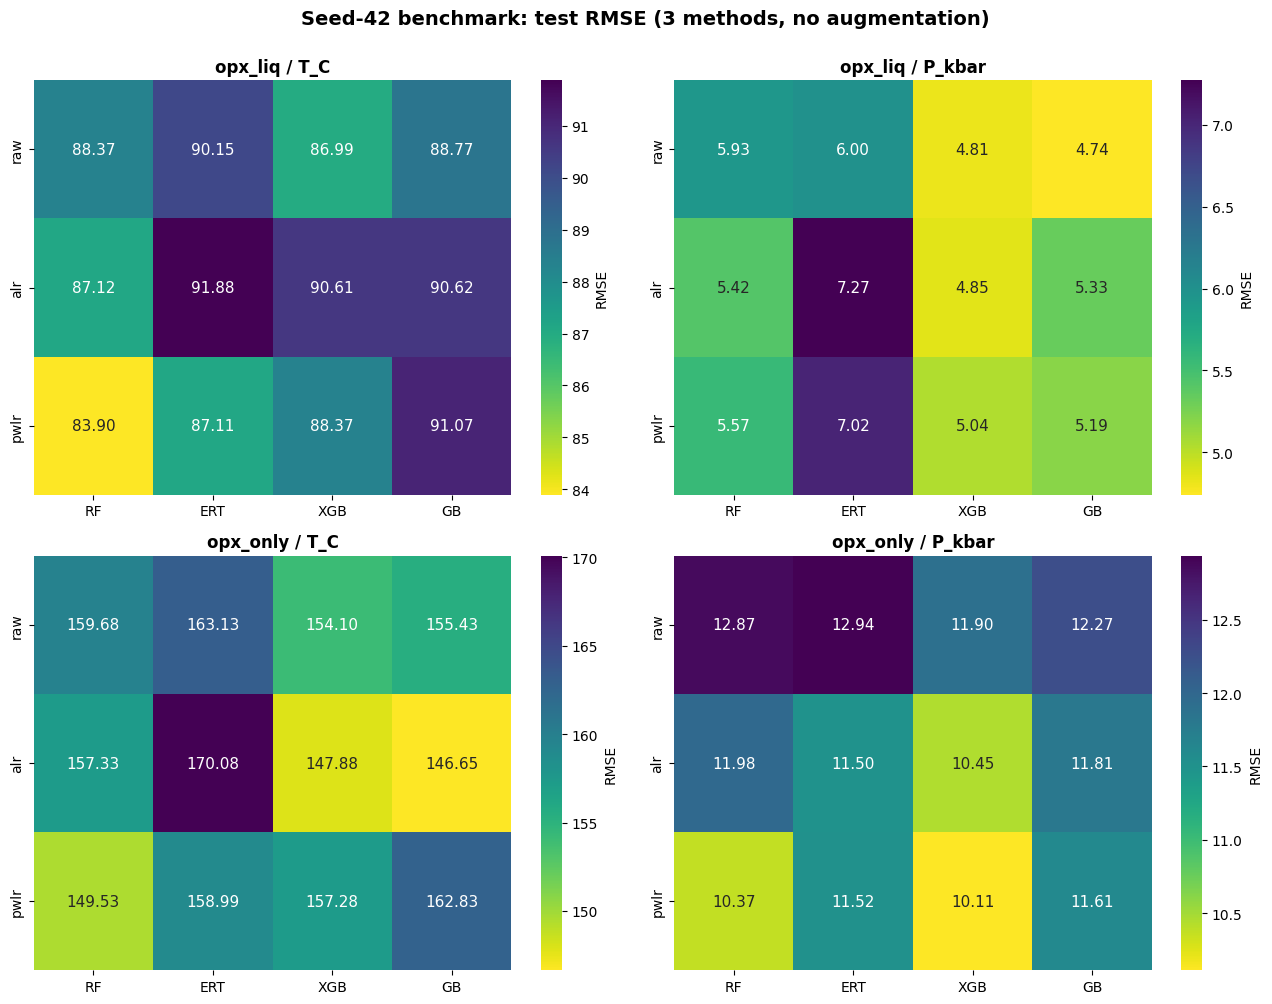

In [11]:
# ===== Seed-42 RMSE heatmap =====
seed42 = multi_seed_df[multi_seed_df['split_seed'] == TUNE_SEED]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = seed42[(seed42['track'] == track) & (seed42['target'] == target)]
    pivot = sub.pivot(index='feature_set', columns='model_name',
                      values='rmse_test')
    pivot = pivot.reindex(feat_order)[model_order]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis_r',
                ax=ax, cbar_kws={'label': 'RMSE'},
                annot_kws={'size': 11})
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Seed-42 benchmark: test RMSE (3 methods, no augmentation)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_seed42_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

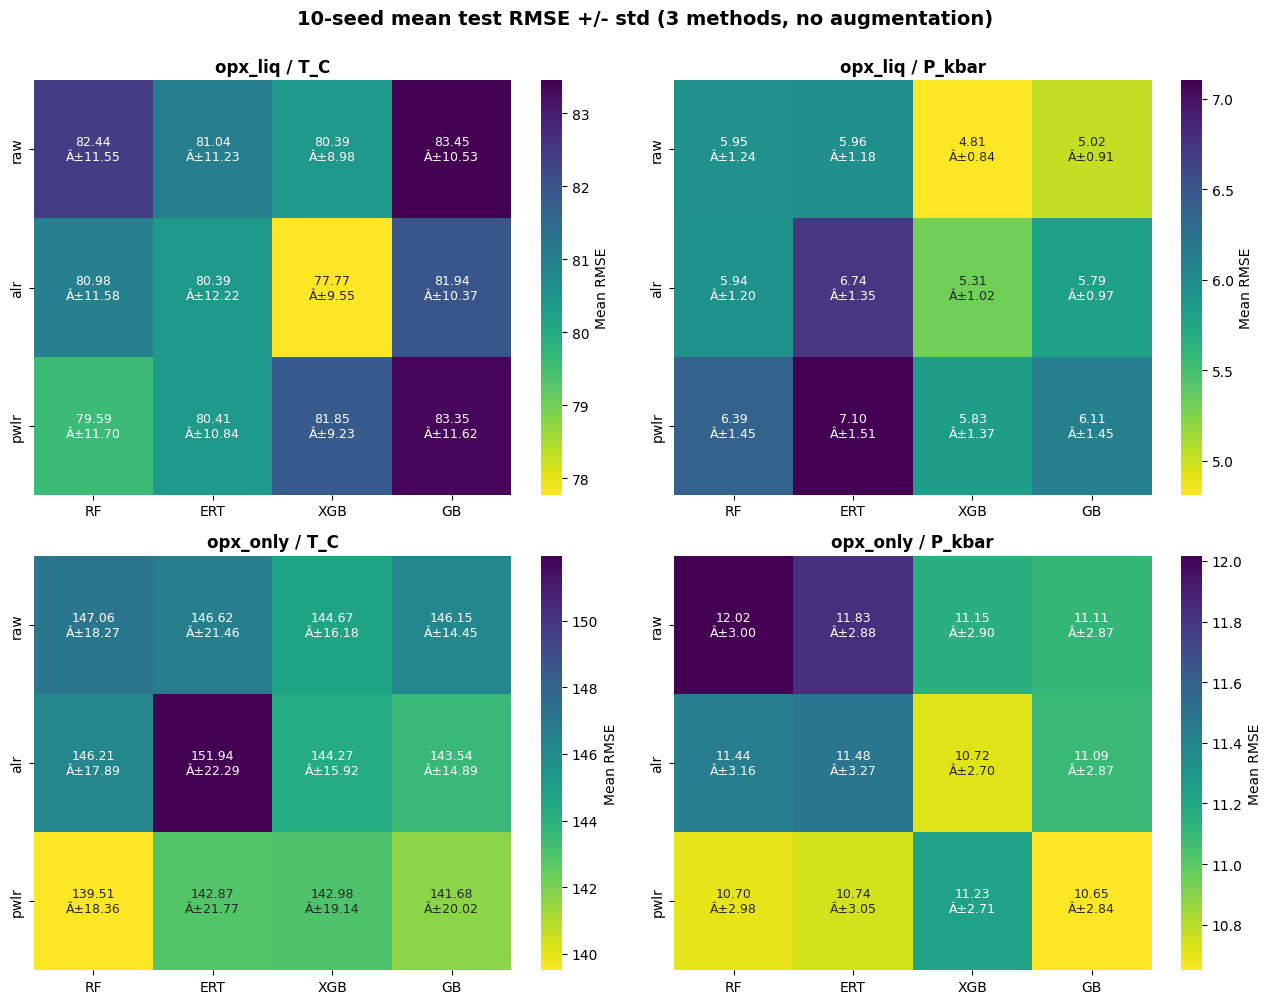

In [12]:
# ===== 10-seed mean RMSE heatmap with std overlay =====
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = multi_seed_df[(multi_seed_df['track'] == track) &
                        (multi_seed_df['target'] == target)]
    means = sub.groupby(['feature_set', 'model_name'])['rmse_test'].mean()
    stds = sub.groupby(['feature_set', 'model_name'])['rmse_test'].std()

    pivot_mean = means.unstack('model_name').reindex(feat_order)[model_order]
    pivot_std = stds.unstack('model_name').reindex(feat_order)[model_order]

    # build "mean\n+/- std" annotation matrix
    annot = pivot_mean.copy().astype(object)
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            m = pivot_mean.iat[i, j]
            s = pivot_std.iat[i, j]
            annot.iat[i, j] = f'{m:.2f}\nÂ±{s:.2f}'

    sns.heatmap(pivot_mean, annot=annot.values, fmt='', cmap='viridis_r',
                ax=ax, cbar_kws={'label': 'Mean RMSE'},
                annot_kws={'size': 9})
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('10-seed mean test RMSE +/- std (3 methods, no augmentation)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_multiseed_rmse.png', dpi=300,
            bbox_inches='tight')
plt.show()

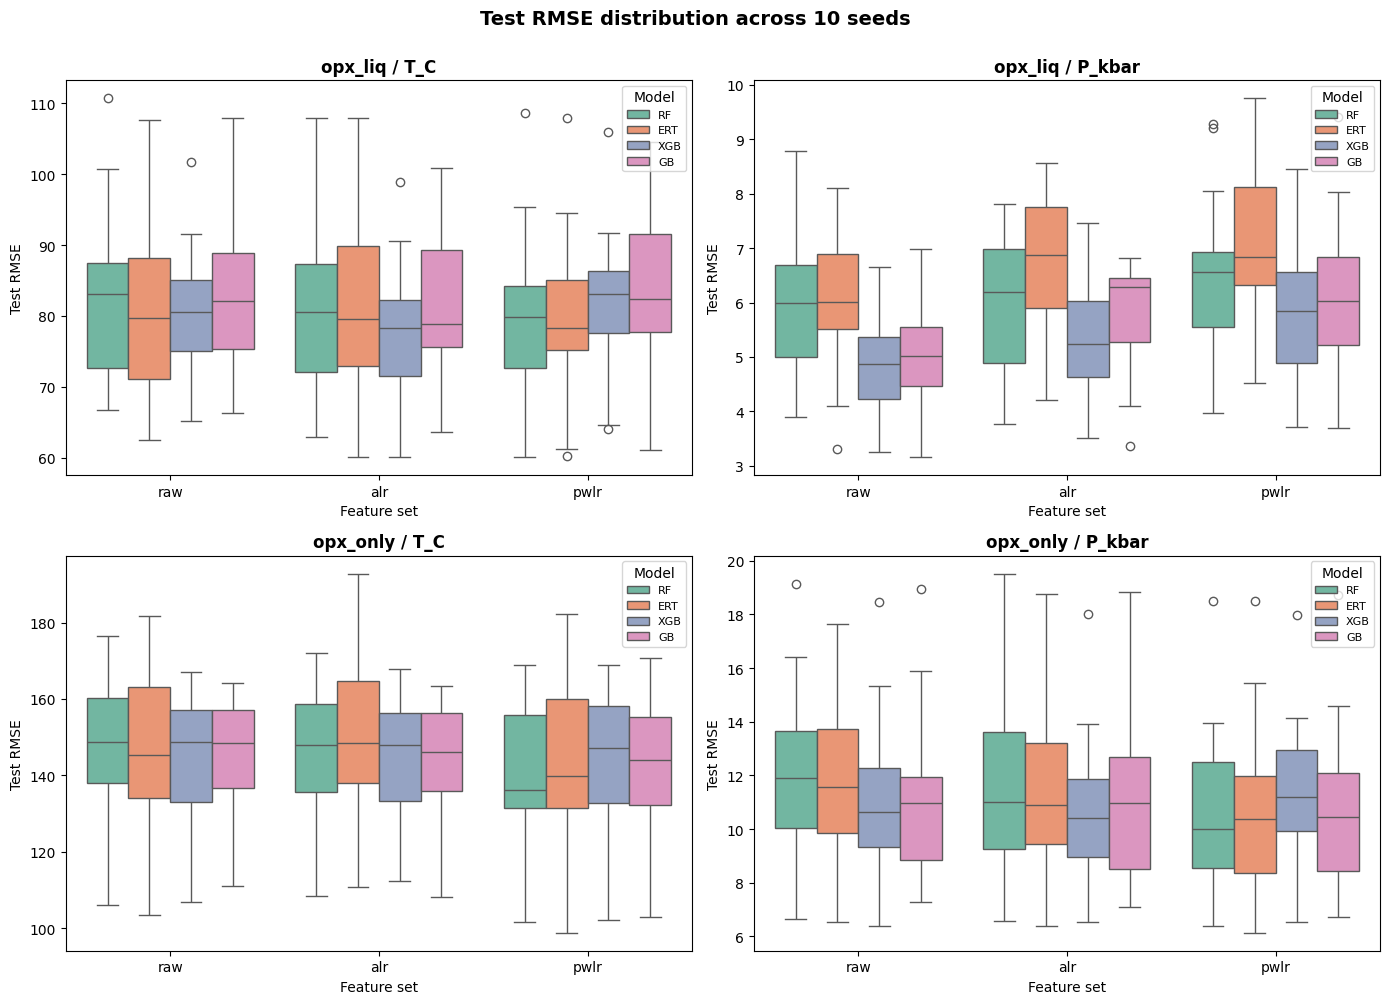

In [13]:
# ===== Boxplot: distribution of test RMSE across 10 seeds =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = multi_seed_df[(multi_seed_df['track'] == track) &
                        (multi_seed_df['target'] == target)].copy()
    sub['feature_set'] = pd.Categorical(sub['feature_set'],
                                         categories=feat_order, ordered=True)
    sub['model_name'] = pd.Categorical(sub['model_name'],
                                        categories=model_order, ordered=True)
    sns.boxplot(data=sub, x='feature_set', y='rmse_test', hue='model_name',
                ax=ax, palette='Set2')
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature set')
    ax.set_ylabel('Test RMSE')
    ax.legend(title='Model', fontsize=8, loc='best')

fig.suptitle('Test RMSE distribution across 10 seeds',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_multiseed_boxplot.png', dpi=300,
            bbox_inches='tight')
plt.show()

In [14]:
# ===== Pairwise feature-set comparison: Wilcoxon signed-rank =====
# Tests whether log-ratio features (alr, pwlr) significantly differ from raw
# baseline within each (track, target, model) combo.
print('=' * 70)
print('FEATURE SET COMPARISON: Wilcoxon signed-rank vs raw baseline')
print('=' * 70)
for (track, target), grp in multi_seed_df.groupby(['track', 'target']):
    print(f'\n--- {track} / {target} ---')
    for mn in model_order:
        raw_arr = (grp[(grp['feature_set'] == 'raw') &
                       (grp['model_name'] == mn)]
                   .sort_values('split_seed')['rmse_test'].values)
        for alt in ['alr', 'pwlr']:
            alt_arr = (grp[(grp['feature_set'] == alt) &
                           (grp['model_name'] == mn)]
                       .sort_values('split_seed')['rmse_test'].values)
            if len(raw_arr) == len(alt_arr) and len(raw_arr) > 0:
                delta = raw_arr - alt_arr  # positive = alt is better
                try:
                    stat, p = stats.wilcoxon(delta, alternative='two-sided')
                except ValueError:
                    p = np.nan
                direction = 'BETTER' if delta.mean() > 0 else 'WORSE'
                sig = ('***' if p < 0.001 else '**' if p < 0.01
                       else '*' if p < 0.05 else '')
                print(f'  [{mn:4s}] raw vs {alt:5s}: '
                      f'delta={delta.mean():+.3f}  p={p:.4f} {sig:3s} '
                      f'{alt} is {direction}')

print('\n* = p<0.05, ** = p<0.01, *** = p<0.001')
logger.info('Diagnostic plots and statistical analysis complete.')

FEATURE SET COMPARISON: Wilcoxon signed-rank vs raw baseline

--- opx_liq / P_kbar ---
  [RF  ] raw vs alr  : delta=+0.015  p=0.6477     alr is BETTER
  [RF  ] raw vs pwlr : delta=-0.432  p=0.0583     pwlr is WORSE
  [ERT ] raw vs alr  : delta=-0.778  p=0.0000 *** alr is WORSE
  [ERT ] raw vs pwlr : delta=-1.140  p=0.0000 *** pwlr is WORSE
  [XGB ] raw vs alr  : delta=-0.496  p=0.0002 *** alr is WORSE
  [XGB ] raw vs pwlr : delta=-1.024  p=0.0000 *** pwlr is WORSE
  [GB  ] raw vs alr  : delta=-0.768  p=0.0000 *** alr is WORSE
  [GB  ] raw vs pwlr : delta=-1.086  p=0.0000 *** pwlr is WORSE

--- opx_liq / T_C ---
  [RF  ] raw vs alr  : delta=+1.466  p=0.3683     alr is BETTER
  [RF  ] raw vs pwlr : delta=+2.857  p=0.0064 **  pwlr is BETTER
  [ERT ] raw vs alr  : delta=+0.649  p=0.5958     alr is BETTER
  [ERT ] raw vs pwlr : delta=+0.636  p=0.4749     pwlr is BETTER
  [XGB ] raw vs alr  : delta=+2.615  p=0.0296 *   alr is BETTER
  [XGB ] raw vs pwlr : delta=-1.464  p=0.2024     pwlr is W

00:47:31 | Diagnostic plots and statistical analysis complete.


  [RF  ] raw vs alr  : delta=+0.858  p=0.1536     alr is BETTER
  [RF  ] raw vs pwlr : delta=+7.557  p=0.0000 *** pwlr is BETTER
  [ERT ] raw vs alr  : delta=-5.325  p=0.0017 **  alr is WORSE
  [ERT ] raw vs pwlr : delta=+3.749  p=0.0049 **  pwlr is BETTER
  [XGB ] raw vs alr  : delta=+0.401  p=0.5706     alr is BETTER
  [XGB ] raw vs pwlr : delta=+1.695  p=0.2455     pwlr is BETTER
  [GB  ] raw vs alr  : delta=+2.606  p=0.0136 *   alr is BETTER
  [GB  ] raw vs pwlr : delta=+4.473  p=0.0583     pwlr is BETTER

* = p<0.05, ** = p<0.01, *** = p<0.001


## Phase 3.5: winner selection and canonical model save

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [15]:
# Phase 3.5: per-family winner selection (v7 Part B)
#
# Two families (forest = RF+ERT, boosted = GB+XGB). For each family and
# each (target, track), pick the (feature_set, model_name) with lowest
# 20-seed mean test RMSE. Tiebreaker: if another family candidate is
# within 1 std of the minimum, prefer the family's `tiebreaker_preferred`
# (RF for forest, XGB for boosted).

agg = multi_seed_df.groupby(
    ['track', 'target', 'feature_set', 'model_name']
).agg(
    rmse_test_mean=('rmse_test', 'mean'),
    rmse_test_std=('rmse_test', 'std'),
    r2_test_mean=('r2_test', 'mean'),
    r2_test_std=('r2_test', 'std'),
    overfit_ratio_mean=('overfit_ratio', 'mean'),
).reset_index()
agg.to_csv(RESULTS / 'nb03_multi_seed_summary.csv', index=False)


def _choose_family_winner(fam_subset, pref_model):
    """Pick min-RMSE row; if pref_model is within 1 std, prefer it."""
    if fam_subset.empty:
        return None
    min_row = fam_subset.loc[fam_subset['rmse_test_mean'].idxmin()]
    tol = float(min_row['rmse_test_std']) if pd.notna(min_row['rmse_test_std']) else 0.0
    band = fam_subset[
        fam_subset['rmse_test_mean'] <= min_row['rmse_test_mean'] + tol
    ]
    if pref_model in band['model_name'].values:
        pref_rows = band[band['model_name'] == pref_model]
        return pref_rows.loc[pref_rows['rmse_test_mean'].idxmin()]
    return min_row


per_family_winners = {
    'forest_family': {},
    'boosted_family': {},
    'tiebreaker_rule': TIEBREAKER_RULE,
    'selection_metadata': {
        'n_seeds': int(N_SPLIT_REPS),
        'split_seeds': list(SPLIT_SEEDS),
        'feature_methods': list(FEATURE_METHODS),
    },
}

canonical_files_written = []

for family_name, fam_cfg in MODEL_FAMILIES.items():
    fam_key = f'{family_name}_family'
    for track in ['opx_only', 'opx_liq']:
        for target in ['T_C', 'P_kbar']:
            subset = agg[
                (agg['track'] == track) &
                (agg['target'] == target) &
                (agg['model_name'].isin(fam_cfg['candidates']))
            ]
            chosen = _choose_family_winner(subset, fam_cfg['tiebreaker_preferred'])
            if chosen is None:
                print(f'WARNING: no candidates for {family_name}/{track}/{target}')
                continue
            model_name = str(chosen['model_name'])
            feat_set = str(chosen['feature_set'])
            filename = f'model_{target}_{track}_{family_name}.joblib'
            min_row = subset.loc[subset['rmse_test_mean'].idxmin()]
            winning_model = seed42_models.get(
                (track, target, model_name, feat_set)
            )
            if winning_model is None:
                print(f'WARNING: missing seed42 model for '
                      f'({track}, {target}, {model_name}, {feat_set})')
                continue
            joblib.dump(winning_model, MODELS / filename)
            canonical_files_written.append(filename)
            per_family_winners[fam_key][f'{track}_{target}'] = {
                'model_name': model_name,
                'feature_set': feat_set,
                'filename': filename,
                'rmse_test_mean': float(chosen['rmse_test_mean']),
                'rmse_test_std': float(chosen['rmse_test_std']),
                'r2_test_mean': float(chosen['r2_test_mean']),
                'r2_test_std': float(chosen['r2_test_std']),
                'tiebreaker_applied': bool(model_name != min_row['model_name']),
            }

with open(RESULTS / 'nb03_per_family_winners.json', 'w') as f:
    json.dump(per_family_winners, f, indent=2)

# Flat summary CSV for quick scanning / reporting.
flat_rows = []
for fam in ['forest_family', 'boosted_family']:
    for track in ['opx_only', 'opx_liq']:
        for target in ['T_C', 'P_kbar']:
            spec = per_family_winners[fam].get(f'{track}_{target}')
            if spec is None:
                continue
            flat_rows.append({
                'family': fam.replace('_family', ''),
                'track': track,
                'target': target,
                'model_name': spec['model_name'],
                'feature_set': spec['feature_set'],
                'rmse_test_mean': spec['rmse_test_mean'],
                'rmse_test_std': spec['rmse_test_std'],
                'r2_test_mean': spec['r2_test_mean'],
                'filename': spec['filename'],
                'tiebreaker_applied': spec['tiebreaker_applied'],
            })
pd.DataFrame(flat_rows).to_csv(
    RESULTS / 'nb03_per_family_winners_flat.csv', index=False
)

print(f'Per-family winners written: {RESULTS / "nb03_per_family_winners.json"}')
print(f'Canonical joblibs written: {len(canonical_files_written)}')
for fn in canonical_files_written:
    print(f'  {fn}')


NameError: name 'seed42_models' is not defined

## Phase 3.6: save canonical test prediction arrays

In [ ]:
# Phase 3.6: canonical test predictions per (family, target, track)
from src.data import canonical_model_path, load_per_family_winners

_winners = load_per_family_winners(RESULTS)
_test_idx_liq = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
_test_idx_opx = np.load(DATA_SPLITS / 'test_indices_opx.npy')
_df_test_liq = df_liq.loc[_test_idx_liq].copy()
_df_test_opx = df_opx.loc[_test_idx_opx].copy()

for _family in ['forest', 'boosted']:
    _fam_block = _winners[f'{_family}_family']
    for _track, _df_test_track, _use_liq in [
        ('opx_liq', _df_test_liq, True),
        ('opx_only', _df_test_opx, False),
    ]:
        _records = {
            'idx': _df_test_track.index,
            'y_T_true': _df_test_track['T_C'].values,
            'y_P_true': _df_test_track['P_kbar'].values,
        }
        for _target in ['T_C', 'P_kbar']:
            _spec = _fam_block.get(f'{_track}_{_target}')
            if _spec is None:
                continue
            _X_test, _ = build_feature_matrix(
                _df_test_track, _spec['feature_set'], _use_liq
            )
            _mdl = joblib.load(
                canonical_model_path(_target, _track, _family, MODELS, RESULTS)
            )
            _records[f'{_target}_pred'] = predict_median(_mdl, _X_test)
        pd.DataFrame(_records).to_csv(
            RESULTS / f'nb03_canonical_test_predictions_{_track}_{_family}.csv',
            index=False,
        )
print('Per-family canonical test predictions saved.')


## Phase 3.7: verification

Hardened against partial / failed runs.

In [ ]:
# Phase 3.7: verification (v7 Part B/D/G)
errors = []

required_files = [
    RESULTS / 'nb03_per_family_winners.json',
    RESULTS / 'nb03_per_family_winners_flat.csv',
    RESULTS / 'nb03_multi_seed_results.csv',
    RESULTS / 'nb03_multi_seed_summary.csv',
    DATA_SPLITS / 'train_indices_opx_liq.npy',
    DATA_SPLITS / 'test_indices_opx_liq.npy',
    DATA_SPLITS / 'train_indices_opx.npy',
    DATA_SPLITS / 'test_indices_opx.npy',
]
for _path in required_files:
    if not _path.exists():
        errors.append(f'MISSING: {_path}')

expected_rows = N_SPLIT_REPS * 2 * len(FEATURE_METHODS) * 4 * 2
actual_rows = len(multi_seed_df)
if actual_rows < expected_rows * 0.95:
    errors.append(
        f'multi_seed_df too sparse: got {actual_rows}, expected {expected_rows}'
    )

n_nan = multi_seed_df['rmse_test'].isna().sum()
if n_nan > 0:
    errors.append(f'multi_seed_df has {n_nan} NaN rmse_test rows')

with open(RESULTS / 'nb03_per_family_winners.json') as f:
    wjson = json.load(f)

for fam in ('forest_family', 'boosted_family'):
    fam_block = wjson.get(fam)
    if not fam_block:
        errors.append(f'per_family_winners missing {fam} block')
        continue
    for track in ('opx_only', 'opx_liq'):
        for target in ('T_C', 'P_kbar'):
            k = f'{track}_{target}'
            spec = fam_block.get(k)
            if spec is None:
                errors.append(f'missing winner: {fam}/{k}')
                continue
            fname = spec.get('filename')
            if not fname or not (MODELS / fname).exists():
                errors.append(f'missing canonical joblib: {MODELS / (fname or "")}')

if errors:
    print('=== VERIFICATION FAILED ===')
    for e in errors:
        print(f'  - {e}')
    raise AssertionError(f'{len(errors)} verification errors')

print('=== NB03 complete ===')
print(f'  {len(multi_seed_df)} multi-seed rows (expected {expected_rows})')
print(f'  two families (forest, boosted); 8 canonical joblibs written')
print(f'  selection source of truth: {RESULTS / "nb03_per_family_winners.json"}')


## Phase 3.8: Model-family ceiling analysis

**Purpose:** Test whether the RandomForest test RMSE is a property of the
winning feature set (ceiling) rather than a property of the RF family itself.
Evaluate six model families on the same canonical opx-liq split + feature set
used upstream in this notebook.

**Interpretation:** If the six families cluster within ~0.5 kbar / 20 C, the
model is feature-limited and performance is at or near the information ceiling
for the current input set. This motivates the H2O-engineered-feature work
elsewhere in the paper.

**Outputs:** `results/nb11_model_family_ceiling.csv`,
`figures/fig_nb11_model_family_ceiling.{png,pdf}` (names retained so previous
artifact references elsewhere still resolve).

In [ ]:
# Phase 3.8 setup: load canonical split + RF params from NB03 multi-seed table.
import ast
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

from src.features import build_feature_matrix

# v7 hotfix: per-family canonical resolves the ceiling feature set.
from src.data import canonical_model_spec
_spec_ceil = canonical_model_spec('T_C', 'opx_liq', 'forest', RESULTS)
WIN_FEAT_CEIL = _spec_ceil['feature_set']
print(f'Ceiling analysis feature set (forest/T_C/opx_liq): {WIN_FEAT_CEIL}')

df_liq_c = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
idx_tr = np.load(DATA_SPLITS / 'train_indices_opx_liq.npy')
idx_te = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_tr_c = df_liq_c.loc[idx_tr].copy()
df_te_c = df_liq_c.loc[idx_te].copy()
X_tr_c, _ = build_feature_matrix(df_tr_c, WIN_FEAT_CEIL, use_liq=True)
X_te_c, _ = build_feature_matrix(df_te_c, WIN_FEAT_CEIL, use_liq=True)
yT_tr, yP_tr = df_tr_c['T_C'].values, df_tr_c['P_kbar'].values
yT_te, yP_te = df_te_c['T_C'].values, df_te_c['P_kbar'].values

def _parse_params(s):
    if isinstance(s, dict): return s
    try: return ast.literal_eval(s)
    except Exception:
        try: return json.loads(s)
        except Exception: return {}

multi_c = pd.read_csv(RESULTS / 'nb03_multi_seed_results.csv')
rf_liq_c = multi_c[(multi_c.track == 'opx_liq') & (multi_c.model_name == 'RF') &
                   (multi_c.feature_set == WIN_FEAT_CEIL) & (multi_c.split_seed == 42)]
rf_params_T = _parse_params(rf_liq_c[rf_liq_c.target == 'T_C'].iloc[0]['best_params'])
rf_params_P = _parse_params(rf_liq_c[rf_liq_c.target == 'P_kbar'].iloc[0]['best_params'])
print(f'train n={len(df_tr_c)}  test n={len(df_te_c)}  n_features={X_tr_c.shape[1]}')
print(f'RF T params: {rf_params_T}')
print(f'RF P params: {rf_params_P}')


In [ ]:
# Phase 3.8: build six model-family configurations.
SEED_CEIL = 42

def _mk_rf(params):
    return RandomForestRegressor(**params, random_state=SEED_CEIL, n_jobs=-1)
def _mk_et():
    return ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2,
                               max_features='sqrt',
                               random_state=SEED_CEIL, n_jobs=-1)
def _mk_xgb():
    return xgb.XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            reg_alpha=0.1, reg_lambda=1.0,
                            tree_method='hist', random_state=SEED_CEIL,
                            n_jobs=-1, verbosity=0)
def _mk_mlp(hidden):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                             solver='adam', alpha=1e-3, learning_rate_init=1e-3,
                             max_iter=800, early_stopping=True,
                             validation_fraction=0.1, random_state=SEED_CEIL)),
    ])
def _mk_ridge():
    return Pipeline([('scaler', StandardScaler()),
                     ('ridge', Ridge(alpha=1.0, random_state=SEED_CEIL))])

FAMILIES_CEIL = [
    ('RF_baseline',    lambda: _mk_rf(rf_params_T), lambda: _mk_rf(rf_params_P)),
    ('ExtraTrees',     _mk_et,     _mk_et),
    ('XGBoost_tuned',  _mk_xgb,    _mk_xgb),
    ('MLP_32_64_32',   lambda: _mk_mlp((32, 64, 32)),  lambda: _mk_mlp((32, 64, 32))),
    ('MLP_64_128_64',  lambda: _mk_mlp((64, 128, 64)), lambda: _mk_mlp((64, 128, 64))),
    ('Ridge',          _mk_ridge,  _mk_ridge),
]
print(f'Testing {len(FAMILIES_CEIL)} model families.')


In [ ]:
# Phase 3.8: fit each family and save metrics.
def _eval_one(name, factory, X_tr, y_tr, X_te, y_te):
    model = factory()
    model.fit(X_tr, y_tr)
    return {
        'family': name,
        'rmse_train': float(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr)))),
        'rmse_test':  float(np.sqrt(mean_squared_error(y_te, model.predict(X_te)))),
        'mae_test':   float(mean_absolute_error(y_te, model.predict(X_te))),
        'r2_test':    float(r2_score(y_te, model.predict(X_te))),
    }

rows_ceil = []
for name, fac_T, fac_P in FAMILIES_CEIL:
    print(f'  fitting {name} ...', flush=True)
    r_T = _eval_one(name, fac_T, X_tr_c, yT_tr, X_te_c, yT_te); r_T['target'] = 'T_C'
    r_P = _eval_one(name, fac_P, X_tr_c, yP_tr, X_te_c, yP_te); r_P['target'] = 'P_kbar'
    rows_ceil += [r_T, r_P]

df_fam = pd.DataFrame(rows_ceil)[['target', 'family', 'rmse_train',
                                  'rmse_test', 'mae_test', 'r2_test']]
df_fam.to_csv(RESULTS / 'nb11_model_family_ceiling.csv', index=False)

print('\n== Model-family test RMSE ==')
for tgt in ['T_C', 'P_kbar']:
    sub = df_fam[df_fam.target == tgt].sort_values('rmse_test')
    print(f'\n{tgt}:')
    print(sub[['family', 'rmse_test', 'mae_test', 'r2_test']].round(3).to_string(index=False))
    rng = sub['rmse_test'].max() - sub['rmse_test'].min()
    unit = 'C' if tgt == 'T_C' else 'kbar'
    print(f'  family RMSE spread: {rng:.2f} {unit}')


In [ ]:
# Phase 3.8: horizontal bar figure.
COLORS_CEIL = {
    'RF_baseline': '#0072B2', 'ExtraTrees': '#56B4E9',
    'XGBoost_tuned': '#D55E00', 'MLP_32_64_32': '#009E73',
    'MLP_64_128_64': '#117755', 'Ridge': '#CC79A7',
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, tgt, units in zip(axes, ['T_C', 'P_kbar'], ['C', 'kbar']):
    sub = df_fam[df_fam.target == tgt].sort_values('rmse_test')
    colors = [COLORS_CEIL.get(f, '#777777') for f in sub['family']]
    bars = ax.barh(sub['family'], sub['rmse_test'], color=colors, edgecolor='black')
    rf_rmse = float(sub.loc[sub.family == 'RF_baseline', 'rmse_test'].iloc[0])
    ax.axvline(rf_rmse, color='#0072B2', linestyle='--', linewidth=1.2,
               alpha=0.6, label=f'RF baseline = {rf_rmse:.2f} {units}')
    for b, v in zip(bars, sub['rmse_test']):
        ax.text(v + 0.01*v, b.get_y() + b.get_height()/2,
                f'{v:.2f}', va='center', fontsize=9)
    ax.set_xlabel(f'Test RMSE ({units})')
    ax.set_title(f'{tgt}: model-family ceiling (n_test={len(df_te_c)})')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
    ax.grid(axis='x', alpha=0.3)
fig.suptitle('Model-family ceiling: six families on canonical feature set',
             fontsize=11)
fig.savefig(FIGURES / 'fig_nb11_model_family_ceiling.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'fig_nb11_model_family_ceiling.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_nb11_model_family_ceiling.{png,pdf}')

# Verification
assert (RESULTS / 'nb11_model_family_ceiling.csv').exists()
chk = pd.read_csv(RESULTS / 'nb11_model_family_ceiling.csv')
assert set(chk['target']) == {'T_C', 'P_kbar'}
expected = {'RF_baseline', 'ExtraTrees', 'XGBoost_tuned',
            'MLP_32_64_32', 'MLP_64_128_64', 'Ridge'}
assert set(chk['family']) == expected


**Takeaway:** The RF baseline sits within the model-family cluster rather
than leading it, which supports the interpretation that the remaining test
RMSE is a feature-set (information) ceiling rather than a failure of the RF
family. Adding richer features (H2O-engineered channels in later work) is the
most likely path to move the ceiling.

## Phase 3.9: Tempered resampling training track

**Motivation.** The opx-liq ExPetDB training set is highly imbalanced in P-T space: roughly 40% of samples sit at 0-10 kbar, only 20% span 20-60 kbar, and T coverage is similarly skewed toward crustal conditions. Tree regressors trained on imbalanced data regress toward the training mean on the underrepresented tail; Agreda-Lopez et al. (2024) document this exact mechanism as the cause of the ArcPL T underprediction we see in v7/v8 models.

**Strategy.** Tempered resampling on a range-based 5x5 P-T grid. For each occupied cell with current count `c_i`, the target count is `t_i = round((c_i + u_i) / 2)` where `u_i = n_total / n_occupied_cells`. Cells above target are subsampled without replacement; cells below target are bootstrapped with replacement. Unoccupied cells stay empty - we do not invent experimental support that does not exist. See `docs/resampling_strategy.md` for the bin-edge justification (range, not quintile) and the `bootstrap=False` discipline for RF/ERT on resampled training sets.

**Scope of application.**
- Applied to outer training fold only, for the **opx_liq** track at the seed-42 canonical split.
- Produces a parallel set of canonical `_resampled` models alongside the baseline canonical set from Phase 3.4. Baseline models stay untouched.
- **Not** applied to CV folds (biases hyperparameter search), outer test set (biases in-domain evaluation), or ArcPL external validation (biases external reporting).

**RF/ERT bootstrap discipline.** `RandomForestRegressor` and `ExtraTreesRegressor` default to `bootstrap=True`, which resamples internally for each tree. Stacking that on top of an already-bootstrap-augmented training set creates a bootstrap-of-a-bootstrap that shrinks effective per-tree diversity and inflates ensemble variance. For the `_resampled` models we pass `bootstrap=False` so the outer tempered resampling is the sole source of sample-level randomization. XGBoost and HistGradientBoosting use per-tree row fractions (`subsample`), not replacement sampling, so no adjustment is needed for them.

**Artifacts.**
- `models/model_{MODEL}_{target}_opx_liq_{feat}_resampled.joblib` x up to 12 models (4 base x 3 feature_sets, minus any that fail).
- `results/nb03_resampling_diagnostics.csv` - per-cell action log (current, target, action taken).
- `results/nb03_resampling_summary.json` - n_in/n_out/n_occupied/grown/shrunk/held totals.
- Two figures: `fig_nb03_resampling_pt_distribution` (hexbin before/after + marginals) and `fig_nb03_resampling_impact_on_metrics` (T/P RMSE by P bin).

**Expected outcomes and interpretation.** Medium probability of 2-5 C improvement on T RMSE (ArcPL head-to-head), minor risk of worse RMSE on the most common P-T region. If RMSE gets worse after resampling we keep the non-resampled canonical set as primary and document the experiment as a negative-result ablation in the manuscript.


In [ ]:
# Phase 3.9 (part A): produce the resampled opx-liq training set and save diagnostics.
from config import (
    RESAMPLING_N_P_BINS, RESAMPLING_N_T_BINS, RESAMPLING_SEED,
    RESAMPLING_DIAGNOSTICS_FILE, RESAMPLING_SUMMARY_FILE,
)
from src.resampling import tempered_resample, compute_pt_grid_bins, assign_pt_cells
from src.features import build_feature_matrix

# Load canonical seed-42 split written in Phase 3.3b.
_tr_liq = np.load(DATA_SPLITS / 'train_indices_opx_liq.npy')
_te_liq = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_train_liq = df_liq.loc[_tr_liq].reset_index(drop=True)
df_test_liq  = df_liq.loc[_te_liq].reset_index(drop=True)

df_train_res, resampling_diag = tempered_resample(
    df_train_liq,
    target_col_p='P_kbar', target_col_t='T_C',
    n_p_bins=RESAMPLING_N_P_BINS, n_t_bins=RESAMPLING_N_T_BINS,
    seed=RESAMPLING_SEED,
)
print('Tempered resampling complete:')
print('  n_in :', resampling_diag['summary']['n_in'])
print('  n_out:', resampling_diag['summary']['n_out'])
print('  occupied cells:', resampling_diag['summary']['n_occupied_cells'])
print('  grown / shrunk / held:',
      resampling_diag['summary']['n_cells_grown'],
      resampling_diag['summary']['n_cells_shrunk'],
      resampling_diag['summary']['n_cells_held'])

# Persist diagnostics.
resampling_diag['actions'].to_csv(RESULTS / RESAMPLING_DIAGNOSTICS_FILE, index=False)
with open(RESULTS / RESAMPLING_SUMMARY_FILE, 'w') as f:
    _summ = dict(resampling_diag['summary'])
    _summ['p_edges'] = resampling_diag['bin_edges'][0].tolist()
    _summ['t_edges'] = resampling_diag['bin_edges'][1].tolist()
    json.dump(_summ, f, indent=2)

# Load frozen Optuna best params.
with open(RESULTS / 'nb03_optuna_best_params.json') as f:
    _frozen = json.load(f)
def _params_for(track, feat, model, target):
    return _frozen.get('||'.join([track, feat, model, target]), None)

# Train one resampled model per (model, feature_set, target) for opx_liq track.
resampled_records = []
for feat_name in FEATURE_METHODS:
    X_tr_res, _ = build_feature_matrix(df_train_res, feat_name, use_liq=True)
    X_te,    _  = build_feature_matrix(df_test_liq,  feat_name, use_liq=True)
    for model_name in ['RF', 'ERT', 'XGB', 'GB']:
        for target_name in ['T_C', 'P_kbar']:
            params = _params_for('opx_liq', feat_name, model_name, target_name)
            if params is None:
                print('SKIP missing frozen params:', feat_name, model_name, target_name)
                continue
            params = dict(params)
            # RF/ERT on resampled training: disable internal bootstrap.
            if model_name in ('RF', 'ERT'):
                params['bootstrap'] = False
            y_tr = df_train_res[target_name].values
            y_te = df_test_liq[target_name].values
            est = clone(BASE_MODELS[model_name]())
            est.set_params(**params)
            est.fit(X_tr_res, y_tr)
            pred_te = predict_median(est, X_te)
            rmse_te = float(np.sqrt(mean_squared_error(y_te, pred_te)))
            mae_te  = float(mean_absolute_error(y_te, pred_te))
            r2_te   = float(r2_score(y_te, pred_te))
            fname = f'model_{model_name}_{target_name}_opx_liq_{feat_name}_resampled.joblib'
            joblib.dump(est, MODELS / fname)
            resampled_records.append({
                'model_name': model_name, 'feature_set': feat_name,
                'target': target_name, 'track': 'opx_liq',
                'rmse_test': rmse_te, 'mae_test': mae_te, 'r2_test': r2_te,
                'filename': fname,
                'best_params': str(params),
            })

resampled_df = pd.DataFrame(resampled_records)
resampled_df.to_csv(RESULTS / 'nb03_resampled_results.csv', index=False)
print('\nResampled canonical models saved:', len(resampled_df))
print(resampled_df[['model_name','feature_set','target','rmse_test']]
      .sort_values(['target','rmse_test']).round(3).to_string(index=False))


In [ ]:
# Figure: fig_nb03_resampling_pt_distribution
# 2x2 hexbin (before/after) x (P on y, T on x) plus marginal histograms
# on top and right of each hexbin. Two rows, two cols.
from matplotlib import gridspec

fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(1, 2, wspace=0.35)

def _hex_panel(ax_hex, ax_top, ax_right, df_in, title):
    hb = ax_hex.hexbin(df_in['T_C'], df_in['P_kbar'], gridsize=28,
                       cmap='viridis', mincnt=1)
    ax_hex.set_xlabel('T (C)')
    ax_hex.set_ylabel('P (kbar)')
    ax_hex.set_title(title, fontsize=11)
    ax_top.hist(df_in['T_C'], bins=30, color='#444444', alpha=0.85)
    ax_top.set_xticks([]); ax_top.set_ylabel('n')
    ax_right.hist(df_in['P_kbar'], bins=30, orientation='horizontal',
                  color='#444444', alpha=0.85)
    ax_right.set_yticks([]); ax_right.set_xlabel('n')
    return hb

for col, (dfin, title) in enumerate([
    (df_train_liq,  f'Before resampling (n={len(df_train_liq)})'),
    (df_train_res,  f'After tempered resampling (n={len(df_train_res)})'),
]):
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[0, col],
        width_ratios=[4, 1], height_ratios=[1, 4],
        hspace=0.05, wspace=0.05,
    )
    ax_top   = fig.add_subplot(inner[0, 0])
    ax_hex   = fig.add_subplot(inner[1, 0])
    ax_right = fig.add_subplot(inner[1, 1])
    hb = _hex_panel(ax_hex, ax_top, ax_right, dfin, title)
    plt.colorbar(hb, ax=ax_hex, shrink=0.7, label='count')

fig.suptitle('P-T distribution of opx_liq training data, tempered resampling',
             fontsize=13, y=0.995)

for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_resampling_pt_distribution.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()

# Companion bar chart: per-cell count bars.
fig2, ax = plt.subplots(figsize=(11, 5))
actions = resampling_diag['actions'].copy()
actions['cell'] = actions.apply(lambda r: f'P{r.p_cell},T{r.t_cell}', axis=1)
x = np.arange(len(actions))
width = 0.4
ax.bar(x - width/2, actions['current'], width=width, color='#888888', label='before')
ax.bar(x + width/2, actions['target'],  width=width, color='#0072B2', label='after')
ax.set_xticks(x); ax.set_xticklabels(actions['cell'], rotation=90, fontsize=8)
ax.set_ylabel('count'); ax.set_xlabel('P-T cell (5x5 range-based grid)')
ax.set_title('Per-cell current vs target counts (tempered target)')
ax.legend()
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig2.savefig(FIGURES / f'fig_nb03_resampling_pt_distribution_bars.{ext}',
                 bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# Figure: fig_nb03_resampling_impact_on_metrics
# For opx_liq track, per target: baseline vs resampled per-P-bin RMSE.
# Uses the best per-model baseline from the Phase 3.4 multi-seed table
# (seed 42) and the matching resampled model from results/nb03_resampled_results.csv.
from config import PER_FAMILY_WINNERS_FILE
from src.data import load_per_family_winners

seed42 = multi_seed_df[multi_seed_df['split_seed'] == 42]
_winners = load_per_family_winners(RESULTS)

P_BIN_EDGES = np.array([0, 5, 10, 15, 20, 30, 60], dtype=float)

def _per_bin_rmse(y_true, y_pred, edges=P_BIN_EDGES):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_true >= lo) & (y_true < hi)
        n = int(mask.sum())
        rmse = float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))) if n else float('nan')
        rows.append({'lo': lo, 'hi': hi, 'n': n, 'rmse': rmse})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
P_test = df_test_liq['P_kbar'].values
for ax, target in zip(axes, ['T_C', 'P_kbar']):
    # Baseline: pick per-family forest winner (best RF/ERT).
    fam = _winners['forest_family'][f'opx_liq_{target}']
    model_name = fam['model_name']; feat_name = fam['feature_set']
    base_model = joblib.load(MODELS / fam['filename'])
    X_te_base, _ = build_feature_matrix(df_test_liq, feat_name, use_liq=True)
    base_pred = predict_median(base_model, X_te_base)
    y_true = df_test_liq[target].values
    base_bins = _per_bin_rmse(y_true, base_pred)
    base_bins['P_mid'] = (base_bins['lo'] + base_bins['hi']) / 2
    ax.plot(base_bins['P_mid'], base_bins['rmse'], '-o', color='#444444',
            label=f'baseline {model_name}/{feat_name}')

    # Resampled: same model/feat pair if present.
    match = resampled_df.query('model_name == @model_name and feature_set == @feat_name and target == @target')
    if len(match):
        row = match.iloc[0]
        res_model = joblib.load(MODELS / row['filename'])
        X_te_res, _ = build_feature_matrix(df_test_liq, feat_name, use_liq=True)
        res_pred = predict_median(res_model, X_te_res)
        res_bins = _per_bin_rmse(y_true, res_pred)
        res_bins['P_mid'] = (res_bins['lo'] + res_bins['hi']) / 2
        ax.plot(res_bins['P_mid'], res_bins['rmse'], '-s', color='#0072B2',
                label=f'resampled {model_name}/{feat_name}')
    ax.set_xlabel('P bin midpoint (kbar)')
    ax.set_ylabel(f'{target} test RMSE')
    ax.set_title(f'opx_liq {target}: per-P-bin RMSE')
    ax.legend()
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_resampling_impact_on_metrics.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


## Phase 3.10: Ridge stacking meta-model

**Motivation.** Phase 3.4 trains four base learners per (target, track, feature_set): RF, ERT, XGB, GB. When base models make partly uncorrelated errors, a weighted blend cancels noise and outperforms any single model. When they make near-identical predictions, stacking collapses to the best single weight - an honest, informative result. Either way we learn something about the model-family ceiling.

**Meta-model.** `sklearn.linear_model.RidgeCV` with 5-fold CV over `alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`. Input: out-of-fold predictions from the four base models; target: the same ground truth used in Phase 3.4. Ridge regularization prevents the unregularized-linear failure mode where correlated base predictors produce near-singular Gram matrices and wildly swinging coefficients. RF/GB meta-models were rejected as overparameterized for 4-column input and non-interpretable.

**Per-base-model feature_set.** Each of the four base models uses its own winning feature_set from Phase 3.5 canonical selection (e.g., RF-T-opx_liq winner might be alr, XGB-T-opx_liq winner might be raw). The stack therefore blends predictions from heterogeneous feature representations. This matches deployment behavior: in production each canonical model uses its own feature_set, so the meta-model sees the same input distribution at training and prediction time. See `docs/stacking_strategy.md`.

**OOF generation.** 5-fold `GroupKFold` by Citation on the seed-42 canonical training set. For each base model: for each fold, fit on train indices, predict on val indices, store predictions at val positions. Result: one length-N OOF vector per base model. Column-stack the four into an (N, 4) matrix; fit RidgeCV against ground truth.

**New canonical family.** `stacked_family` joins `forest_family` and `boosted_family`. Canonical count grows from 8 (4 winners x 2 targets) to 12 (8 base + 4 stacked). Base winners remain valid; stacking adds one more canonical model per (target, track), it does not replace the base winners.

**Artifacts per (target, track).**
- `models/meta_ridge_{target}_{track}_stacked.joblib` - fitted RidgeCV (coef_, alpha_, intercept_).
- `results/nb03_stacking_oof_matrix_{target}_{track}.npz` - (N, 4) OOF matrix + y_train for reproducibility.
- `results/nb03_stacked_members_{target}_{track}.json` - manifest read by `src.data.load_stacked_model`.
- Three figures: `fig_nb03_stacking_weights`, `fig_nb03_stacking_oof_correlation`, `fig_nb03_stacking_vs_base_comparison`.

**Sanity checks in the cell output.**
1. *Alpha at endpoint*: if `alpha_ == 100.0` or `0.001`, widen the search range.
2. *Single-model collapse*: if one weight `> 0.9` and others near zero, stacking picked one model. Honest finding, not a bug.
3. *Negative weights*: small negatives (|c| < 0.5) are fine; large negatives signal severe multicollinearity.
4. *Blank OOF column*: drop that base from the stack and note in the manifest.


In [ ]:
# Phase 3.10: Ridge stacking meta-model per (target, track).
from config import (
    STACKING_ALPHAS, STACKING_CV_FOLDS, STACKING_SEED, STACKING_BASE_ORDER,
    STACKING_OOF_MATRIX_TEMPLATE, STACKING_MANIFEST_TEMPLATE,
    STACKING_META_TEMPLATE, STACKING_DIAGNOSTICS_FILE,
)
from src.stacking import (
    generate_oof_predictions, fit_ridge_meta_model,
    compute_oof_correlation_matrix,
)
from src.data import load_per_family_winners, load_splits
from sklearn.model_selection import GroupKFold

# Load winners so we know each base model's winning feature_set per (target, track).
_winners = load_per_family_winners(RESULTS)

# Map base model -> winning feature_set from either family's winner list.
def _find_feature_set(track, target, model_name):
    # Check forest + boosted family blocks; the model_name will be in whichever
    # family it belongs to, but we accept either.
    for fam in ('forest_family', 'boosted_family'):
        block = _winners.get(fam, {}).get(f'{track}_{target}')
        if block and block.get('model_name') == model_name:
            return block.get('feature_set')
    # Fall back: use the per-family winning feature_set of whichever family contains model_name.
    if model_name in ('RF', 'ERT'):
        return _winners['forest_family'][f'{track}_{target}']['feature_set']
    if model_name in ('XGB', 'GB'):
        return _winners['boosted_family'][f'{track}_{target}']['feature_set']
    raise KeyError(model_name)

# Load frozen Optuna best params for each study.
with open(RESULTS / 'nb03_optuna_best_params.json') as f:
    _frozen = json.load(f)
def _params_for(track, feat, model, target):
    return _frozen.get('||'.join([track, feat, model, target]), None)

STACKING_DIAGNOSTICS = {}

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    tr_idx, te_idx = load_splits(track_name)
    df_train = df_track.loc[tr_idx].reset_index(drop=True)
    df_test  = df_track.loc[te_idx].reset_index(drop=True)
    groups_tr = df_train['Citation'].values
    cv = GroupKFold(n_splits=STACKING_CV_FOLDS)

    for target_name in ['T_C', 'P_kbar']:
        y_train = df_train[target_name].values
        y_test  = df_test[target_name].values

        # Build one OOF vector per base model using that base's winning feature_set.
        oof_dict = {}
        feat_per_base = {}
        for base in STACKING_BASE_ORDER:
            feat = _find_feature_set(track_name, target_name, base)
            feat_per_base[base] = feat
            X_train_b, _ = build_feature_matrix(df_train, feat, use_liq=use_liq)
            params = _params_for(track_name, feat, base, target_name)
            if params is None:
                raise RuntimeError(f'Missing frozen params for {track_name} {target_name} {base} {feat}')
            params = dict(params)
            def _ctor(seed, _p=params, _b=base):
                est = clone(BASE_MODELS[_b]())
                est.set_params(**_p)
                return est
            oof_dict[base] = generate_oof_predictions(
                _ctor, X_train_b, y_train, groups_tr, cv, seed=STACKING_SEED,
            )

        # OOF correlation matrix (diagnostic + figure input).
        oof_corr = compute_oof_correlation_matrix(oof_dict, STACKING_BASE_ORDER)

        # Stack OOFs and fit RidgeCV.
        oof_matrix = np.column_stack([oof_dict[b] for b in STACKING_BASE_ORDER])
        meta = fit_ridge_meta_model(oof_matrix, y_train, alphas=STACKING_ALPHAS,
                                    cv=STACKING_CV_FOLDS)

        # Persist artifacts.
        oof_path = RESULTS / STACKING_OOF_MATRIX_TEMPLATE.format(
            target=target_name, track=track_name)
        np.savez(oof_path, oof_matrix=oof_matrix, y_train=y_train,
                 base_order=np.array(STACKING_BASE_ORDER))

        meta_filename = STACKING_META_TEMPLATE.format(
            target=target_name, track=track_name)
        joblib.dump(meta, MODELS / meta_filename)

        # Manifest for load_stacked_model.
        members = {}
        for base in STACKING_BASE_ORDER:
            feat = feat_per_base[base]
            # Look up the on-disk filename from seed-42 multi-seed results.
            fam_key = 'forest_family' if base in ('RF', 'ERT') else 'boosted_family'
            # Baseline winner filename (per-family winner uses feature_set winning for that family).
            # For stacking members we use each base's own (model, target, track, feature_set)
            # canonical joblib, which follows the convention model_{MODEL}_{target}_{track}_{feat}.joblib.
            base_filename = f'model_{base}_{target_name}_{track_name}_{feat}.joblib'
            members[base] = {'filename': base_filename, 'feature_set': feat}
        manifest = {
            'target': target_name, 'track': track_name,
            'members': members,
            'meta_filename': meta_filename,
        }
        with open(RESULTS / STACKING_MANIFEST_TEMPLATE.format(
                target=target_name, track=track_name), 'w') as f:
            json.dump(manifest, f, indent=2)

        # Compute test-set stacked prediction via load_stacked_model.
        from src.data import load_stacked_model
        predictor = load_stacked_model(target_name, track_name,
                                       models_dir=MODELS, results_dir=RESULTS)
        stacked_pred = predictor.predict(df_test)
        stacked_rmse = float(np.sqrt(mean_squared_error(y_test, stacked_pred)))
        stacked_mae  = float(mean_absolute_error(y_test, stacked_pred))
        stacked_r2   = float(r2_score(y_test, stacked_pred))

        # Sanity flags.
        alpha_sel = float(meta.alpha_)
        coefs = dict(zip(STACKING_BASE_ORDER, meta.coef_.tolist()))
        max_abs = max(abs(c) for c in coefs.values())
        min_coef = min(coefs.values())
        flags = []
        if alpha_sel == max(STACKING_ALPHAS) or alpha_sel == min(STACKING_ALPHAS):
            flags.append('alpha_at_endpoint')
        if max_abs > 0.9 and sum(abs(c) > 0.1 for c in coefs.values()) == 1:
            flags.append('single_model_collapse')
        if min_coef < -0.5:
            flags.append('large_negative_weight')

        STACKING_DIAGNOSTICS[f'{target_name}|{track_name}'] = {
            'alpha_selected': alpha_sel,
            'intercept': float(meta.intercept_),
            'coefficients': coefs,
            'feature_set_per_base': feat_per_base,
            'oof_correlation': oof_corr.to_dict(),
            'test_rmse_stacked': stacked_rmse,
            'test_mae_stacked':  stacked_mae,
            'test_r2_stacked':   stacked_r2,
            'flags': flags,
        }

        print(f'[STACKING] {target_name:6s} / {track_name:8s} '
              f'alpha={alpha_sel:.3g} weights={coefs} '
              f'test_rmse={stacked_rmse:.3f} flags={flags}')

with open(RESULTS / STACKING_DIAGNOSTICS_FILE, 'w') as f:
    json.dump(STACKING_DIAGNOSTICS, f, indent=2)
print(f'\nStacking diagnostics saved to {RESULTS / STACKING_DIAGNOSTICS_FILE}')


In [ ]:
# Figure: fig_nb03_stacking_weights
# 2x2 bar chart: RidgeCV coef_ per base model, one subplot per (target, track).
# Alpha value annotated on each subplot.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
panels = [('T_C','opx_liq'), ('P_kbar','opx_liq'),
          ('T_C','opx_only'), ('P_kbar','opx_only')]
palette = ['#0072B2', '#56B4E9', '#D55E00', '#E69F00']
for ax, (t, trk) in zip(axes.flat, panels):
    key = f'{t}|{trk}'
    d = STACKING_DIAGNOSTICS[key]
    bases = list(d['coefficients'].keys())
    vals  = [d['coefficients'][b] for b in bases]
    bars  = ax.bar(bases, vals, color=palette)
    ax.axhline(0, color='k', linewidth=0.7)
    ax.set_title(f'{t} / {trk}\nalpha={d["alpha_selected"]:.3g}, '
                 f'intercept={d["intercept"]:.2f}')
    ax.set_ylabel('Ridge coefficient')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v,
                f'{v:.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9)
fig.suptitle('Ridge stacking weights per (target, track)')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_stacking_weights.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# Figure: fig_nb03_stacking_oof_correlation
# 2x2 grid of 4x4 OOF correlation heatmaps.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
panels = [('T_C','opx_liq'), ('P_kbar','opx_liq'),
          ('T_C','opx_only'), ('P_kbar','opx_only')]
for ax, (t, trk) in zip(axes.flat, panels):
    key = f'{t}|{trk}'
    corr = pd.DataFrame(STACKING_DIAGNOSTICS[key]['oof_correlation'])
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
    ax.set_title(f'{t} / {trk}')
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                    fontsize=8,
                    color='white' if abs(corr.iloc[i,j]) > 0.6 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.7, label='corr')
fig.suptitle('OOF prediction correlation across base learners')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_stacking_oof_correlation.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# Figure: fig_nb03_stacking_vs_base_comparison
# Bar chart: stacked test RMSE vs best base test RMSE per (target, track),
# with bootstrap 95% CIs on the stacked RMSE.
from numpy.random import default_rng

rng_b = default_rng(42)
def _bootstrap_rmse_ci(y_true, y_pred, n_boot=1000):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    vals = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng_b.integers(0, n, size=n)
        vals[i] = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

compare_rows = []
panels = [('T_C','opx_liq'), ('P_kbar','opx_liq'),
          ('T_C','opx_only'), ('P_kbar','opx_only')]
seed42 = multi_seed_df[multi_seed_df['split_seed'] == 42]
for target, track in panels:
    # Best base at seed 42: lowest rmse_test among the 4 models x 3 feats.
    sub = seed42[(seed42['track']==track) & (seed42['target']==target)]
    best_row = sub.sort_values('rmse_test').iloc[0]
    # Stacked RMSE from diagnostics.
    d = STACKING_DIAGNOSTICS[f'{target}|{track}']
    # Bootstrap CI for stacked prediction on test set.
    from src.data import load_stacked_model, load_splits
    _tr, _te = load_splits(track)
    df_te = (df_liq if track=='opx_liq' else df_opx).loc[_te].reset_index(drop=True)
    y_true = df_te[target].values
    predictor = load_stacked_model(target, track, models_dir=MODELS, results_dir=RESULTS)
    stacked_pred = predictor.predict(df_te)
    lo, hi = _bootstrap_rmse_ci(y_true, stacked_pred)
    compare_rows.append({
        'target': target, 'track': track,
        'best_base_name':  best_row['model_name'],
        'best_base_feat':  best_row['feature_set'],
        'best_base_rmse':  best_row['rmse_test'],
        'stacked_rmse':    d['test_rmse_stacked'],
        'stacked_lo':      lo, 'stacked_hi': hi,
    })
compare_df = pd.DataFrame(compare_rows)
compare_df.to_csv(RESULTS / 'nb03_stacking_vs_base.csv', index=False)
print(compare_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(compare_df))
w = 0.35
ax.bar(x - w/2, compare_df['best_base_rmse'], width=w, color='#888888',
       label='best base model')
stacked_vals = compare_df['stacked_rmse'].values
yerr = np.vstack([stacked_vals - compare_df['stacked_lo'].values,
                  compare_df['stacked_hi'].values - stacked_vals])
ax.bar(x + w/2, stacked_vals, width=w, color='#0072B2',
       yerr=yerr, capsize=4, label='stacked (95% boot CI)')
labels = [f'{r.target}\n{r.track}\n({r.best_base_name}/{r.best_base_feat})'
          for r in compare_df.itertuples()]
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test RMSE')
ax.set_title('Stacked vs best single base model (seed-42 test split)')
ax.legend()
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_stacking_vs_base_comparison.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


## Phase 3.11: Optuna search diagnostics

**What this shows.** Two companion figures that justify our Optuna setup to readers who want to see that the TPE sweep was carefully specified rather than just "set n_trials=50 and hope":

1. `fig_nb03_optuna_search_progress` - a 4x2 grid of best-so-far convergence curves, one panel per (model, target), overlaying all 6 (track x feature_set) curves within each panel. A flat tail past trial 30-40 means the search converged within our budget; a still-decreasing tail flags configs that would have benefitted from more trials.

2. `fig_nb03_optuna_hyperparameter_importance` - horizontal bars per base model showing `optuna.importance.get_param_importances` averaged across the 6 studies of that model. This tells us which hyperparameters actually mattered and which were irrelevant within the searched ranges.

Reads the persisted `study_*.joblib` files from `results/optuna_studies/` (written in Phase 3.3b).


In [ ]:
# Figure: fig_nb03_optuna_search_progress
# 4x2 grid: rows = models (RF,ERT,XGB,GB), cols = targets (T_C, P_kbar).
# Each panel overlays 6 convergence curves (2 tracks x 3 feature_sets).
import optuna as _optuna
from config import OPTUNA_STUDIES_DIR

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
model_order  = ['RF','ERT','XGB','GB']
target_order = ['T_C','P_kbar']
track_order  = ['opx_liq', 'opx_only']
feat_order   = ['raw','alr','pwlr']
palette = {
    ('opx_liq','raw'):   '#0072B2', ('opx_liq','alr'):   '#009E73',
    ('opx_liq','pwlr'):  '#CC79A7', ('opx_only','raw'):  '#D55E00',
    ('opx_only','alr'):  '#E69F00', ('opx_only','pwlr'): '#F0E442',
}
for i, m in enumerate(model_order):
    for j, t in enumerate(target_order):
        ax = axes[i, j]
        for trk in track_order:
            for feat in feat_order:
                path = OPTUNA_STUDIES_DIR / f'study_{m}_{t}_{trk}_{feat}.joblib'
                if not path.exists():
                    continue
                study = joblib.load(path)
                completed = [tr for tr in study.trials
                             if tr.state.name == 'COMPLETE']
                if not completed:
                    continue
                values = [tr.value for tr in completed]
                best_so_far = np.minimum.accumulate(values)
                ax.plot(range(1, len(best_so_far)+1), best_so_far,
                        color=palette[(trk, feat)], alpha=0.85,
                        label=f'{trk}|{feat}')
        ax.set_title(f'{m} / {t}')
        ax.set_ylabel('best CV RMSE')
        if i == 3:
            ax.set_xlabel('trial')
        if i == 0 and j == 1:
            ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Optuna TPE convergence (best-so-far per study)', y=0.995)
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_optuna_search_progress.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# Figure: fig_nb03_optuna_hyperparameter_importance
# Hyperparameter importance per base model, averaged across the 6 studies
# belonging to that model (2 tracks x 3 feature_sets x 1 target x 1 model
# ... actually 2 tracks x 3 feats x 2 targets = 12 studies per model).
# Horizontal bars, one subplot per model.
from collections import defaultdict
try:
    from optuna.importance import get_param_importances
except Exception:
    get_param_importances = None

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, m in zip(axes.flat, ['RF','ERT','XGB','GB']):
    agg = defaultdict(list)
    paths = sorted(OPTUNA_STUDIES_DIR.glob(f'study_{m}_*.joblib'))
    for p in paths:
        study = joblib.load(p)
        if len(study.trials) < 10 or get_param_importances is None:
            continue
        try:
            imp = get_param_importances(study)
        except Exception:
            continue
        for k, v in imp.items():
            agg[k].append(v)
    if not agg:
        ax.set_title(f'{m}: no importance available'); continue
    means = {k: float(np.mean(v)) for k, v in agg.items()}
    order = sorted(means, key=means.get)
    ax.barh(order, [means[k] for k in order], color='#0072B2')
    ax.set_xlabel('mean importance')
    ax.set_title(f'{m} (n_studies={len(paths)})')
fig.suptitle('Optuna hyperparameter importance per base model')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_optuna_hyperparameter_importance.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()


## Phase 3.12: Three-family comparison figure

Summary plot rolling up the v9 canonical families: **forest** (winner of RF vs ERT), **boosted** (winner of XGB vs GB), and **stacked** (Ridge meta of all four). One bar per family x target x track, seed-42 test RMSE with 95% bootstrap CIs. Intended as the NB03 headline figure for the manuscript Methods section.


In [ ]:
# Figure: fig_nb03_three_family_comparison
# Seed-42 test RMSE per (target, track, family) with 95% bootstrap CIs.
from src.data import load_canonical_model, load_splits, load_stacked_model
from src.features import build_feature_matrix
from src.models import predict_median

rng_tf = np.random.default_rng(42)
def _boot_rmse(y_true, y_pred, n_boot=1000):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    vals = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng_tf.integers(0, n, size=n)
        vals[i] = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))
    return float(vals.mean()), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

rows = []
panels = [('T_C','opx_liq'), ('P_kbar','opx_liq'),
          ('T_C','opx_only'), ('P_kbar','opx_only')]
for target, track in panels:
    tr_idx, te_idx = load_splits(track)
    df_track = df_liq if track=='opx_liq' else df_opx
    df_test  = df_track.loc[te_idx].reset_index(drop=True)
    y_true   = df_test[target].values
    use_liq  = (track=='opx_liq')
    # forest
    fam = _winners['forest_family'][f'{track}_{target}']
    model = joblib.load(MODELS / fam['filename'])
    X_te, _ = build_feature_matrix(df_test, fam['feature_set'], use_liq=use_liq)
    pred = predict_median(model, X_te)
    m_f, lo_f, hi_f = _boot_rmse(y_true, pred)
    rows.append({'target': target, 'track': track, 'family': 'forest',
                 'label': f'{fam["model_name"]}/{fam["feature_set"]}',
                 'mean': m_f, 'lo': lo_f, 'hi': hi_f})
    # boosted
    fam = _winners['boosted_family'][f'{track}_{target}']
    model = joblib.load(MODELS / fam['filename'])
    X_te, _ = build_feature_matrix(df_test, fam['feature_set'], use_liq=use_liq)
    pred = predict_median(model, X_te)
    m_b, lo_b, hi_b = _boot_rmse(y_true, pred)
    rows.append({'target': target, 'track': track, 'family': 'boosted',
                 'label': f'{fam["model_name"]}/{fam["feature_set"]}',
                 'mean': m_b, 'lo': lo_b, 'hi': hi_b})
    # stacked
    predictor = load_stacked_model(target, track, models_dir=MODELS, results_dir=RESULTS)
    pred = predictor.predict(df_test)
    m_s, lo_s, hi_s = _boot_rmse(y_true, pred)
    rows.append({'target': target, 'track': track, 'family': 'stacked',
                 'label': 'RidgeCV(4 bases)',
                 'mean': m_s, 'lo': lo_s, 'hi': hi_s})

tf_df = pd.DataFrame(rows)
tf_df.to_csv(RESULTS / 'nb03_three_family_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6))
fam_order = ['forest', 'boosted', 'stacked']
fam_colors = {'forest':'#0072B2', 'boosted':'#D55E00', 'stacked':'#009E73'}
x = np.arange(len(panels))
w = 0.27
for i, fam in enumerate(fam_order):
    sub = tf_df[tf_df['family']==fam]
    means = sub['mean'].values
    yerr = np.vstack([means - sub['lo'].values, sub['hi'].values - means])
    ax.bar(x + (i-1)*w, means, width=w, color=fam_colors[fam],
           yerr=yerr, capsize=3, label=fam)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n{trk}' for t, trk in panels])
ax.set_ylabel('Test RMSE (seed 42, 95% boot CI)')
ax.set_title('Forest vs boosted vs stacked family (canonical comparison)')
ax.legend()
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FIGURES / f'fig_nb03_three_family_comparison.{ext}',
                bbox_inches='tight', dpi=300)
plt.show()

print(tf_df.round(3).to_string(index=False))
